# 04 · Few-Shot Prompting with LLMs

This notebook benchmarks **few-shot prompting strategies** on the QEvasion dataset,
complementing the zero-shot and chain-of-thought approaches in `03_cot_llm.ipynb`.

**Model**: `meta-llama/Meta-Llama-3.1-8B-Instruct` (4-bit quantised via bitsandbytes)

Three few-shot strategies are compared:
1. **Point 1 — One-Shot**: single example from training set
2. **Point 2 — Three-Shot**: one example per clarity class (Clear Reply, Ambivalent, Clear Non-Reply)
3. **Point 3 — Nine-Shot**: one example per evasion sub-class (all 9 fine-grained labels)

For each strategy, results are evaluated on three complementary tasks:
- **Task A**: 3-class clarity classification
- **Task B**: 9-class evasion classification
- **Task C**: Map Task B predictions to Task A classes using the official evasion→clarity mapping

Results are saved to `results/few_shots/` as JSON, CSV and PNG.

**Checkpoint Support**: If interrupted on Colab, re-running resumes from the last checkpoint.

---
### Quick-start
1. Set your HuggingFace token: on Colab use the *Secrets* panel; locally create `.env` (see `.env.example`).
2. Run all cells top to bottom.
3. Results appear in `results/few_shots/`.

## 0 · Setup (Colab only)

In [1]:
# ── Google Colab setup ──────────────────────────────────────────────────────
# This cell is a no-op when running locally.
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # Install all LLM-specific dependencies
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'numpy>=2.0'], check=True)
    subprocess.run(['pip', 'install', '-q',
        'transformers>=4.44.2', 'accelerate>=0.33.0', 'bitsandbytes>=0.43.3',
        'datasets', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas',
        'tqdm', 'python-dotenv'], check=True)
    print('Colab dependencies installed.')
else:
    print('Running locally — skipping Colab setup.')

Mounted at /content/drive
Colab dependencies installed.


In [2]:
# Add project root to sys.path so `src/` is importable from any working directory
import sys
from pathlib import Path

# Move the project to `progettoLLM/` folder in your Drive and update if needed
PROJECT_ROOT = Path('/content/drive/MyDrive/progettoLLM/CLARITY').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)

Project root: /content/drive/MyDrive/progettoLLM/CLARITY


## 1 · Configuration

In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EDIT THIS CELL to change the model or token budgets.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

from src.utils.env_utils import is_colab

MODEL_NAME  = 'meta-llama/Meta-Llama-3.1-8B-Instruct'
TEMPERATURE = 0.05   # lower than CoT for more stable few-shot
SEED        = 42     # must match dataset_loader default for reproducibility

# ── Results directory ──────────────────────────────────────────────────────
# Mirrors the pattern in src/utils/env_utils.py::get_output_dir()
if is_colab():
    SAVE_DIR = Path('/content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots')
else:
    SAVE_DIR = Path('results/few_shots')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Official dataset labels ────────────────────────────────────────────────
# Must match the values used in dataset_loader.py / EVASION_TO_CLARITY
CLARITY_LABELS = ['Clear Reply', 'Ambivalent', 'Clear Non-Reply']
EVASION_LABELS = [
    'Explicit', 'Implicit',
    'General', 'Partial/half-answer',
    'Dodging', 'Deflection',
    'Declining to answer', 'Claims ignorance', 'Clarification',
]

# ── Evasion to Clarity mapping (from paper) ────────────────────────────────
EVASION_TO_CLARITY_MAP = {
    'Explicit': 'Clear Reply',
    'Implicit': 'Ambivalent',
    'General': 'Ambivalent',
    'Partial/half-answer': 'Ambivalent',
    'Dodging': 'Ambivalent',
    'Deflection': 'Ambivalent',
    'Declining to answer': 'Clear Non-Reply',
    'Claims ignorance': 'Clear Non-Reply',
    'Clarification': 'Clear Non-Reply',
}

# ── Token budgets ──────────────────────────────────────────────────────────
MAX_NEW_TOKENS_SHOT = 50    # all few-shot strategies: label only

print('Config OK')
print(f'SAVE_DIR         : {SAVE_DIR}')
print(f'Clarity labels   : {CLARITY_LABELS}')
print(f'Evasion labels   : {EVASION_LABELS}')

Config OK
SAVE_DIR         : /content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots
Clarity labels   : ['Clear Reply', 'Ambivalent', 'Clear Non-Reply']
Evasion labels   : ['Explicit', 'Implicit', 'General', 'Partial/half-answer', 'Dodging', 'Deflection', 'Declining to answer', 'Claims ignorance', 'Clarification']


In [4]:
import os

if IN_COLAB:
    # Colab Secrets — token is never stored in the notebook file.
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
else:
    # Locally: read from .env file (gitignored — never committed).
    # Copy .env.example -> .env and fill in your token.
    try:
        from dotenv import load_dotenv
        load_dotenv(PROJECT_ROOT / '.env')
    except ImportError:
        pass  # python-dotenv is optional locally
    HF_TOKEN = os.environ.get('HF_TOKEN', '')
    if not HF_TOKEN:
        print('[WARNING] HF_TOKEN not set. See .env.example for instructions.')

print(f'HF_TOKEN loaded: {"OK" if HF_TOKEN else "MISSING"}')

HF_TOKEN loaded: OK


## 2 · Load Model

In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
)

print(f'Loading {MODEL_NAME} in 4-bit...')
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, token=HF_TOKEN, trust_remote_code=True
)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map='auto',
    token=HF_TOKEN,
    trust_remote_code=True,
)
model.eval()
print('Model loaded.')
if torch.cuda.is_available():
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Loading meta-llama/Meta-Llama-3.1-8B-Instruct in 4-bit...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Model loaded.
  GPU : Tesla T4
  VRAM: 15.6 GB


## 3 · Load Dataset

In [6]:
from src.data.dataset_loader import load_and_split_dataset

print('Loading ailsntua/QEvasion ...')
ds = load_and_split_dataset(seed=SEED, verbose=True)
print(f'\nDataset loaded. Train split has evasion_label: {"evasion_label" in ds["train"].column_names}')

Loading ailsntua/QEvasion ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

  train       :  3103 samples
  validation  :   345 samples
  test        :   308 samples

Dataset loaded. Train split has evasion_label: True


In [7]:
import pandas as pd
import numpy as np

# Load splits to pandas for easier manipulation
df_train = ds['train'].to_pandas()
df_test = ds['test'].to_pandas()

# Clean clarity labels
df_train['clarity_label'] = df_train['clarity_label'].str.strip()

# ── Task A : 3-class clarity ────────────────────────────────────────────────
df_test_task_a = df_test[
    df_test['clarity_label'].notna() &
    (df_test['clarity_label'].str.strip() != '')
].copy()
df_test_task_a['clarity_label'] = df_test_task_a['clarity_label'].str.strip()

# ── Task B : 9-class evasion ────────────────────────────────────────────────
df_test_task_b = df_test[df_test['evasion_label'].notna()].copy()

print(f'Training set: {len(df_train)} samples')
print(f'  Clarity distribution:\n{df_train["clarity_label"].value_counts()}')
print(f'\nTest set Task A (clarity): {len(df_test_task_a)} samples')
print(f'  {df_test_task_a["clarity_label"].value_counts()}')
print(f'\nTest set Task B (evasion): {len(df_test_task_b)} samples')
print(f'  {df_test_task_b["evasion_label"].value_counts()}')

Training set: 3103 samples
  Clarity distribution:
clarity_label
Ambivalent         1825
Clear Reply         954
Clear Non-Reply     324
Name: count, dtype: int64

Test set Task A (clarity): 308 samples
  clarity_label
Ambivalent         206
Clear Reply         79
Clear Non-Reply     23
Name: count, dtype: int64

Test set Task B (evasion): 308 samples
  evasion_label
Explicit               79
Implicit               67
General                65
Dodging                50
Deflection             20
Declining to answer    11
Claims ignorance        8
Partial/half-answer     4
Clarification           4
Name: count, dtype: int64


## 4 · Selection of Few-Shot Examples from Training Set

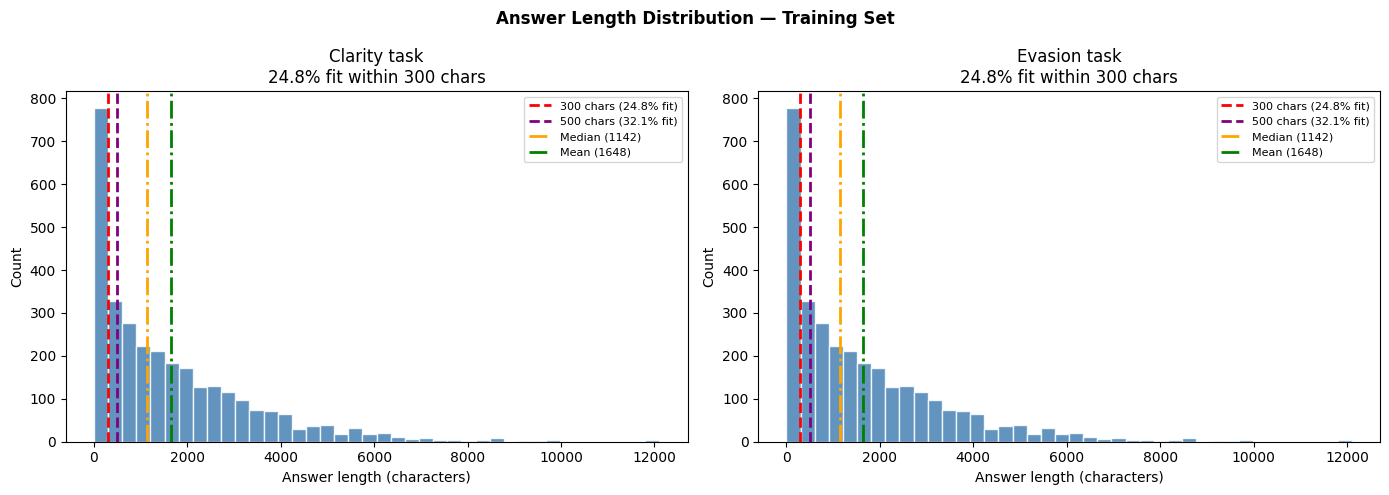


Lunghezza risposta per label — evasion (training set):
                     mean  median  min    max % within 300 % within 500
evasion_label                                                          
Claims ignorance      906     474    9   8235        36.4%        52.7%
Clarification         540      50    5   5975        79.5%        83.1%
Declining to answer   819     244   11   7095        54.2%        64.1%
Deflection           2052    1662   12   9683         8.2%        14.6%
Dodging              1513     822    3  12102        33.7%        40.4%
Explicit             1530    1090    3   9227        24.3%        31.6%
General              1908    1450    4   9637        16.1%        22.7%
Implicit             2167    1765    9   8766        12.5%        18.8%
Partial/half-answer  1981    1316    3   9683        17.6%        27.0%

Lunghezza risposta nel TEST SET (task B):
  Mean:              1856 chars
  Median:            1644 chars
  % within 300:      13.0%
  % within 500:   

In [35]:
# ── CELLA: Analisi lunghezza risposte — versione autonoma ─────────────────

import matplotlib.pyplot as plt
import numpy as np

# Costruisce i DataFrame dal training set già caricato in questo notebook
df_train_clarity_local = df_train[
    df_train['clarity_label'].notna() &
    (df_train['clarity_label'].str.strip() != '')
].copy()

df_train_evasion_local = df_train[
    df_train['evasion_label'].notna() &
    (df_train['evasion_label'].str.strip() != '')
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Answer Length Distribution — Training Set', fontweight='bold')

for ax, df_t, label_col, title in [
    (axes[0], df_train_clarity_local, 'clarity_label', 'Clarity task'),
    (axes[1], df_train_evasion_local, 'evasion_label', 'Evasion task'),
]:
    lengths = df_t['interview_answer'].str.len()
    pct_under_300 = (lengths <= 300).mean() * 100
    pct_under_500 = (lengths <= 500).mean() * 100

    ax.hist(lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(300, color='red',    linestyle='--', linewidth=2,
               label=f'300 chars ({pct_under_300:.1f}% fit)')
    ax.axvline(500, color='purple', linestyle='--', linewidth=2,
               label=f'500 chars ({pct_under_500:.1f}% fit)')
    ax.axvline(lengths.median(), color='orange', linestyle='-.',
               linewidth=2, label=f'Median ({lengths.median():.0f})')
    ax.axvline(lengths.mean(),   color='green',  linestyle='-.',
               linewidth=2, label=f'Mean ({lengths.mean():.0f})')

    ax.set_xlabel('Answer length (characters)')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}\n{pct_under_300:.1f}% fit within 300 chars')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'answer_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistiche per label (evasion) ───────────────────────────────────────
print('\nLunghezza risposta per label — evasion (training set):')
df_train_evasion_local['answer_len'] = \
    df_train_evasion_local['interview_answer'].str.len()

stats = df_train_evasion_local.groupby('evasion_label')['answer_len'].agg(
    mean   = 'mean',
    median = 'median',
    min    = 'min',
    max    = 'max',
).round(0).astype(int)

stats['% within 300'] = df_train_evasion_local.groupby('evasion_label')['answer_len'].apply(
    lambda x: f'{(x <= 300).mean()*100:.1f}%'
)
stats['% within 500'] = df_train_evasion_local.groupby('evasion_label')['answer_len'].apply(
    lambda x: f'{(x <= 500).mean()*100:.1f}%'
)

print(stats.to_string())

# ── Stessa analisi per il test set ────────────────────────────────────────
print('\nLunghezza risposta nel TEST SET (task B):')
test_lengths = df_test_task_b['interview_answer'].str.len()
print(f'  Mean:              {test_lengths.mean():.0f} chars')
print(f'  Median:            {test_lengths.median():.0f} chars')
print(f'  % within 300:      {(test_lengths <= 300).mean()*100:.1f}%')
print(f'  % within 500:      {(test_lengths <= 500).mean()*100:.1f}%')
print(f'  Max:               {test_lengths.max()} chars')

In [36]:
# ─ Select ONE-SHOT example ──────────────────────────────────────────────────
# Pick a single "representative" example: one that is well-classified
# (i.e., has clear and unambiguous signals).
# Strategy: pick the first example with 'Clear Reply' that has a reasonably
# long answer (good signal).

clear_reply_samples = df_train[
    (df_train['clarity_label'] == 'Clear Reply')
].copy()
clear_reply_samples['answer_len'] = clear_reply_samples['interview_answer'].str.len()
one_shot_idx = clear_reply_samples.iloc[
    (clear_reply_samples['answer_len'] - clear_reply_samples['answer_len'].median()).abs().argsort().iloc[0]
].name
one_shot_example = df_train.loc[one_shot_idx]

print('ONE-SHOT Example:')
print(f'  Q: {one_shot_example["question"][:80]}...')
print(f'  A: {one_shot_example["interview_answer"][:100]}...')
print(f'  Label: {one_shot_example["clarity_label"]}')
print()

# ─ Select THREE-SHOT examples ───────────────────────────────────────────────
# One example per clarity class.

three_shot_examples = {}
for clarity_class in CLARITY_LABELS:
    samples = df_train[
        (df_train['clarity_label'] == clarity_class)
    ].copy()
    samples['answer_len'] = samples['interview_answer'].str.len()
    # Pick the median-length example for each class to avoid outliers
    idx = samples.iloc[
        (samples['answer_len'] - samples['answer_len'].median()).abs().argsort().iloc[0]
    ].name
    three_shot_examples[clarity_class] = df_train.loc[idx]

print('THREE-SHOT Examples (one per clarity class):')
for clarity_class, example in three_shot_examples.items():
    print(f'  [{clarity_class}]')
    print(f'    Q: {example["question"][:70]}...')
    print(f'    A: {example["interview_answer"][:80]}...')
print()

# ─ Select NINE-SHOT examples ───────────────────────────────────────────────
# One example per evasion sub-class.
# The training set already has evasion_label (computed with majority vote).
# Use it directly without recalculation.

nine_shot_examples = {}
for evasion_label in EVASION_LABELS:
    samples = df_train[
        (df_train['evasion_label'] == evasion_label)
    ].copy()
    if len(samples) == 0:
        print(f'  [WARNING] No examples found for evasion label: {evasion_label}')
        continue
    samples['answer_len'] = samples['interview_answer'].str.len()
    idx = samples.iloc[
        (samples['answer_len'] - samples['answer_len'].median()).abs().argsort().iloc[0]
    ].name
    nine_shot_examples[evasion_label] = df_train.loc[idx]

print('NINE-SHOT Examples (one per evasion sub-class):')
for evasion_label, example in nine_shot_examples.items():
    print(f'  [{evasion_label}]')
    print(f'    Q: {example["question"][:60]}...')
    print(f'    A: {example["interview_answer"][:70]}...')
print(f'\nTotal 9-shot examples selected: {len(nine_shot_examples)}')

ONE-SHOT Example:
  Q: What did Kim Jong Un say to you to give you the confidence that, for once in the...
  A: Yes, I mean, very fair question. He actually mentioned the fact that they proceeded down a path in t...
  Label: Clear Reply

THREE-SHOT Examples (one per clarity class):
  [Clear Reply]
    Q: What did Kim Jong Un say to you to give you the confidence that, for o...
    A: Yes, I mean, very fair question. He actually mentioned the fact that they procee...
  [Ambivalent]
    Q: Would you be willing to meet with him without condition?...
    A: Well, again, John, there has been no collusion between the Trump campaign and Ru...
  [Clear Non-Reply]
    Q: Why hasn't Vice President Pence followed the CDC guidelines of self-is...
    A: Well, that, I'm going to have to ask that he will give you that information. Wha...

NINE-SHOT Examples (one per evasion sub-class):
  [Explicit]
    Q: What did Kim Jong Un say to you to give you the confidence t...
    A: Yes, I mean, very fair q

## 5 · Inference Utilities

In [37]:
import re
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')


def predict_few_shot(system_prompt: str, question: str, answer: str,
                     max_new_tokens: int = MAX_NEW_TOKENS_SHOT) -> str:
    """
    Few-shot prediction: returns the raw model output string.

    Args:
        system_prompt  : System-role instruction (includes examples).
        question       : Journalist question.
        answer         : Politician answer.
        max_new_tokens : Maximum tokens to generate.
    Returns:
        Raw decoded string from the model.
    """
    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user',   'content': f'QUESTION: {question}\n\nANSWER: {answer}'},
    ]
    prompt_str = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=False
    )
    inputs = tokenizer(
        prompt_str, return_tensors='pt', add_special_tokens=False
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            temperature=TEMPERATURE,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated_ids = out[0][inputs['input_ids'].shape[-1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


def parse_label(raw: str, valid_labels: list) -> str:
    """
    Map raw model output to the closest valid label.
    Tries exact match, then known shortcuts, then partial match.
    Returns 'PARSE_ERROR' if no match is found.
    """
    raw_l = raw.lower().strip()
    for lbl in valid_labels:
        if lbl.lower() == raw_l:
            return lbl
    shortcuts = {
        'non-reply':       'Clear Non-Reply',
        'non reply':       'Clear Non-Reply',
        'clear non reply': 'Clear Non-Reply',
        'clear reply':     'Clear Reply',
        'decline':         'Declining to answer',
        'declining':       'Declining to answer',
        'ignorance':       'Claims ignorance',
        'claims':          'Claims ignorance',
        'partial':         'Partial/half-answer',
        'half-answer':     'Partial/half-answer',
    }
    for key, val in shortcuts.items():
        if key in raw_l and val in valid_labels:
            return val
    for lbl in valid_labels:
        if lbl.lower() in raw_l or raw_l in lbl.lower():
            return lbl
    return 'PARSE_ERROR'


print('Few-shot inference functions defined.')

Few-shot inference functions defined.


In [38]:
# ── Utility to create prompts with examples ────────────────────────────────

def format_example(question: str, answer: str, label: str) -> str:
    return f"""QUESTION: {question}
ANSWER: {answer}
CLASSIFICATION: {label}"""

def create_clarity_prompt_with_examples(examples_list: list) -> str:
    """
    Create a system prompt for 3-class clarity classification with examples.

    Args:
        examples_list: list of (question, answer, clarity_label) tuples
    """
    prompt = """You are a political evasion analyst. Your task is to classify politician answers
into one of three clarity categories:

1. **Clear Reply**: The politician directly addresses the question with a substantive response.
2. **Ambivalent**: The politician provides a mixed or equivocal response that partially addresses the question.
3. **Clear Non-Reply**: The politician evades the question by declining to answer, claiming ignorance, or deflecting.

Carefully analyze the question and answer pair. Return ONLY the exact classification label, nothing else.

Here are examples:\n\n"""

    for i, (q, a, label) in enumerate(examples_list, 1):
        prompt += f"Example {i}:\n"
        prompt += format_example(q, a, label)
        prompt += "\n\n"

    prompt += "Now classify the following question-answer pair:"
    return prompt


def create_evasion_prompt_with_examples(examples_list: list) -> str:
    """
    Create a system prompt for 9-class evasion classification with examples.

    Args:
        examples_list: list of (question, answer, evasion_label) tuples
    """
    prompt = """You are a political evasion analyst. Your task is to classify politician answers
into one of nine evasion sub-categories:

1. **Explicit**: Direct answer without evasion.
2. **Implicit**: Indirect answer that addresses the question obliquely.
3. **General**: Vague or overly general response without specifics.
4. **Partial/half-answer**: Only partially addresses the question.
5. **Dodging**: Avoids answering by changing the subject.
6. **Deflection**: Answers a different interpretation of the question.
7. **Declining to answer**: Explicitly refuses to respond.
8. **Claims ignorance**: States lack of knowledge or information.
9. **Clarification**: Asks for clarification instead of answering.

Carefully analyze the question and answer pair. Return ONLY the exact evasion label, nothing else.

Here are examples:\n\n"""

    for i, (q, a, label) in enumerate(examples_list, 1):
        prompt += f"Example {i}:\n"
        prompt += format_example(q, a, label)
        prompt += "\n\n"

    prompt += "Now classify the following question-answer pair:"
    return prompt


print('Prompt formatting functions defined.')

Prompt formatting functions defined.


In [39]:
# ── Utility to compute metrics ──────────────────────────────────────────────

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import json


def compute_metrics(true_labels: list, pred_labels: list, label_names: list) -> dict:
    """
    Compute accuracy, precision, recall, F1-score.
    """
    acc = accuracy_score(true_labels, pred_labels)
    prec, rec, f1, _ = precision_recall_fscore_support(
        true_labels, pred_labels, labels=label_names, zero_division=0
    )

    return {
        'accuracy': float(acc),
        'precision': {name: float(p) for name, p in zip(label_names, prec)},
        'recall': {name: float(r) for name, r in zip(label_names, rec)},
        'f1': {name: float(f) for name, f in zip(label_names, f1)},
    }


print('Metrics functions defined.')

Metrics functions defined.


In [40]:
# ── Inference with checkpoint support (inspired by 03_cot_llm.ipynb) ────────

def run_inference_few_shot_with_checkpoint(df: pd.DataFrame,
                                            system_prompt: str,
                                            label_col: str,
                                            valid_labels: list,
                                            exp_name: str,
                                            csv_path: str) -> pd.DataFrame:
    """
    Few-shot inference with row-level checkpointing.

    Each row is written to disk immediately after generation.
    If interrupted, re-running resumes from where it stopped.

    Args:
        df            : Test DataFrame.
        system_prompt : System-role instruction.
        label_col     : Column name for ground-truth labels.
        valid_labels  : List of valid output labels.
        exp_name      : Experiment name (used in progress bar).
        csv_path      : Full path to the checkpoint CSV file.
    Returns:
        DataFrame loaded from csv_path (may be partial if interrupted).
    """
    import os
    if os.path.exists(csv_path):
        df_saved = pd.read_csv(csv_path)
        processed_questions = set(df_saved['question'].astype(str))
        print(f'[{exp_name}] Checkpoint found: skipping {len(processed_questions)} rows.')
        mode, header = 'a', False
    else:
        processed_questions = set()
        print(f'[{exp_name}] No checkpoint: starting from scratch.')
        mode, header = 'w', True
    try:
        for _, row in tqdm(df.iterrows(), total=len(df), desc=exp_name):
            q = str(row['question'])
            if q in processed_questions:
                continue
            a    = str(row['interview_answer'])
            true = str(row[label_col])
            try:
                raw  = predict_few_shot(system_prompt, q, a)
                pred = parse_label(raw, valid_labels)
            except Exception as e:
                raw  = f'ERROR: {e}'
                pred = 'PARSE_ERROR'
            record = {
                'question':       q,
                'answer_snippet': a[:150],
                'true_label':     true,
                'pred_label':     pred,
                'raw_output':     raw,
            }
            pd.DataFrame([record]).to_csv(csv_path, mode=mode, header=header, index=False)
            mode, header = 'a', False
    except KeyboardInterrupt:
        print(f'\n[!] Interrupted. Progress saved to {csv_path}')
    return pd.read_csv(csv_path)


print('Checkpoint inference function defined.')

Checkpoint inference function defined.


---
# POINT 1: One-Shot Prompting

## 1A · One-Shot Clarity Classification (3 classes)

In [41]:
# Create one-shot prompt with the selected example
one_shot_clarity_prompt = create_clarity_prompt_with_examples([
    (one_shot_example['question'],
     one_shot_example['interview_answer'],
     one_shot_example['clarity_label'])
])

print('One-Shot Clarity System Prompt:')
print('='*80)
print(one_shot_clarity_prompt)
print('='*80)

One-Shot Clarity System Prompt:
You are a political evasion analyst. Your task is to classify politician answers
into one of three clarity categories:

1. **Clear Reply**: The politician directly addresses the question with a substantive response.
2. **Ambivalent**: The politician provides a mixed or equivocal response that partially addresses the question.
3. **Clear Non-Reply**: The politician evades the question by declining to answer, claiming ignorance, or deflecting.

Carefully analyze the question and answer pair. Return ONLY the exact classification label, nothing else.

Here are examples:

Example 1:
QUESTION: What did Kim Jong Un say to you to give you the confidence that, for once in the history of North Korea, they are not cheating the system and gaming the world and gaming the people who will have to go in and make sure that they're actually giving up their nuclear arsenal? What did he say to you?
ANSWER: Yes, I mean, very fair question. He actually mentioned the fact that

In [42]:
# Run inference with checkpoint
csv_path_1a = SAVE_DIR / '1a_oneshot_clarity_predictions.csv'
df_1a_results = run_inference_few_shot_with_checkpoint(
    df_test_task_a,
    one_shot_clarity_prompt,
    'clarity_label',
    CLARITY_LABELS,
    'Point 1A: One-Shot Clarity',
    str(csv_path_1a)
)

# Compute metrics
metrics_1a = compute_metrics(
    df_1a_results['true_label'].tolist(),
    df_1a_results['pred_label'].tolist(),
    CLARITY_LABELS
)

print(f'\n1A Results — One-Shot Clarity Classification')
print(f'Accuracy: {metrics_1a["accuracy"]:.4f}')
print(f'Per-class F1:')
for label, f1 in metrics_1a['f1'].items():
    print(f'  {label}: {f1:.4f}')

# Save metrics
with open(SAVE_DIR / '1a_oneshot_clarity_metrics.json', 'w') as f:
    json.dump(metrics_1a, f, indent=2)
print(f'\nSaved results to {SAVE_DIR}')

[Point 1A: One-Shot Clarity] No checkpoint: starting from scratch.


Point 1A: One-Shot Clarity: 100%|██████████| 308/308 [08:35<00:00,  1.67s/it]


1A Results — One-Shot Clarity Classification
Accuracy: 0.2338
Per-class F1:
  Clear Reply: 0.3684
  Ambivalent: 0.0097
  Clear Non-Reply: 0.3077

Saved results to /content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots


## 1B · One-Shot Evasion Classification (9 classes)

In [43]:
# Create one-shot evasion prompt
# For evasion, use the one_shot_example but map its clarity to evasion label
one_shot_evasion_label = [k for k, v in EVASION_TO_CLARITY_MAP.items()
                          if v == one_shot_example['clarity_label']][0]

one_shot_evasion_prompt = create_evasion_prompt_with_examples([
    (one_shot_example['question'],
     one_shot_example['interview_answer'],
     one_shot_evasion_label)
])

print('One-Shot Evasion System Prompt:')
print('='*80)
print(one_shot_evasion_prompt)
print('='*80)

One-Shot Evasion System Prompt:
You are a political evasion analyst. Your task is to classify politician answers
into one of nine evasion sub-categories:

1. **Explicit**: Direct answer without evasion.
2. **Implicit**: Indirect answer that addresses the question obliquely.
3. **General**: Vague or overly general response without specifics.
4. **Partial/half-answer**: Only partially addresses the question.
5. **Dodging**: Avoids answering by changing the subject.
6. **Deflection**: Answers a different interpretation of the question.
7. **Declining to answer**: Explicitly refuses to respond.
8. **Claims ignorance**: States lack of knowledge or information.
9. **Clarification**: Asks for clarification instead of answering.

Carefully analyze the question and answer pair. Return ONLY the exact evasion label, nothing else.

Here are examples:

Example 1:
QUESTION: What did Kim Jong Un say to you to give you the confidence that, for once in the history of North Korea, they are not cheating 

In [44]:
# Run inference with checkpoint
csv_path_1b = SAVE_DIR / '1b_oneshot_evasion_predictions.csv'
df_1b_results = run_inference_few_shot_with_checkpoint(
    df_test_task_b,
    one_shot_evasion_prompt,
    'evasion_label',
    EVASION_LABELS,
    'Point 1B: One-Shot Evasion',
    str(csv_path_1b)
)

# Compute metrics
metrics_1b = compute_metrics(
    df_1b_results['true_label'].tolist(),
    df_1b_results['pred_label'].tolist(),
    EVASION_LABELS
)

print(f'\n1B Results — One-Shot Evasion Classification')
print(f'Accuracy: {metrics_1b["accuracy"]:.4f}')
print(f'Per-class F1 (top 5):')
sorted_f1 = sorted(metrics_1b['f1'].items(), key=lambda x: x[1], reverse=True)[:5]
for label, f1 in sorted_f1:
    print(f'  {label}: {f1:.4f}')

# Save metrics
with open(SAVE_DIR / '1b_oneshot_evasion_metrics.json', 'w') as f:
    json.dump(metrics_1b, f, indent=2)

[Point 1B: One-Shot Evasion] No checkpoint: starting from scratch.


Point 1B: One-Shot Evasion: 100%|██████████| 308/308 [08:40<00:00,  1.69s/it]


1B Results — One-Shot Evasion Classification
Accuracy: 0.1169
Per-class F1 (top 5):
  Explicit: 0.2909
  Claims ignorance: 0.2000
  General: 0.1720
  Declining to answer: 0.1538
  Dodging: 0.1270


## 1C · Map One-Shot Evasion Predictions to Clarity (Mapping Validation)

In [45]:
# Map predicted evasion labels to clarity labels using the official mapping
df_1c_results = df_1b_results.copy()
df_1c_results['mapped_clarity_pred'] = df_1c_results['pred_label'].apply(
    lambda x: EVASION_TO_CLARITY_MAP.get(x, 'UNKNOWN')
)
df_1c_results['mapped_clarity_true'] = df_1c_results['true_label'].apply(
    lambda x: EVASION_TO_CLARITY_MAP.get(x, 'UNKNOWN')
)

# Compute metrics on mapped clarity labels
metrics_1c = compute_metrics(
    df_1c_results['mapped_clarity_true'].tolist(),
    df_1c_results['mapped_clarity_pred'].tolist(),
    CLARITY_LABELS
)

print(f'\n1C Results — One-Shot Evasion → Clarity Mapping')
print(f'Accuracy (after mapping): {metrics_1c["accuracy"]:.4f}')
print(f'Per-class F1:')
for label, f1 in metrics_1c['f1'].items():
    print(f'  {label}: {f1:.4f}')
print(f'\nComparison with Task 1A (direct clarity classification):')
print(f'  1A (direct):         {metrics_1a["accuracy"]:.4f}')
print(f'  1C (via evasion):    {metrics_1c["accuracy"]:.4f}')

# Save results
df_1c_results[['question', 'answer_snippet', 'mapped_clarity_true',
                'mapped_clarity_pred', 'true_label', 'pred_label']].to_csv(
    SAVE_DIR / '1c_oneshot_evasion_to_clarity_predictions.csv', index=False
)
with open(SAVE_DIR / '1c_oneshot_evasion_to_clarity_metrics.json', 'w') as f:
    json.dump(metrics_1c, f, indent=2)


1C Results — One-Shot Evasion → Clarity Mapping
Accuracy (after mapping): 0.2305
Per-class F1:
  Clear Reply: 0.2909
  Ambivalent: 0.3696
  Clear Non-Reply: 0.1951

Comparison with Task 1A (direct clarity classification):
  1A (direct):         0.2338
  1C (via evasion):    0.2305


---
# POINT 2: Three-Shot Prompting

## 2A · Three-Shot Clarity Classification (3 classes)

In [46]:
# Create three-shot clarity prompt (one example per clarity class)
three_shot_clarity_examples = [
    (three_shot_examples[label]['question'],
     three_shot_examples[label]['interview_answer'],
     label)
    for label in CLARITY_LABELS
]

three_shot_clarity_prompt = create_clarity_prompt_with_examples(
    three_shot_clarity_examples
)

print('Three-Shot Clarity System Prompt:')
print('='*80)
print(three_shot_clarity_prompt)
print('='*80)

Three-Shot Clarity System Prompt:
You are a political evasion analyst. Your task is to classify politician answers
into one of three clarity categories:

1. **Clear Reply**: The politician directly addresses the question with a substantive response.
2. **Ambivalent**: The politician provides a mixed or equivocal response that partially addresses the question.
3. **Clear Non-Reply**: The politician evades the question by declining to answer, claiming ignorance, or deflecting.

Carefully analyze the question and answer pair. Return ONLY the exact classification label, nothing else.

Here are examples:

Example 1:
QUESTION: What did Kim Jong Un say to you to give you the confidence that, for once in the history of North Korea, they are not cheating the system and gaming the world and gaming the people who will have to go in and make sure that they're actually giving up their nuclear arsenal? What did he say to you?
ANSWER: Yes, I mean, very fair question. He actually mentioned the fact th

In [47]:
# Run inference with checkpoint
csv_path_2a = SAVE_DIR / '2a_threeshot_clarity_predictions.csv'
df_2a_results = run_inference_few_shot_with_checkpoint(
    df_test_task_a,
    three_shot_clarity_prompt,
    'clarity_label',
    CLARITY_LABELS,
    'Point 2A: Three-Shot Clarity',
    str(csv_path_2a)
)

# Compute metrics
metrics_2a = compute_metrics(
    df_2a_results['true_label'].tolist(),
    df_2a_results['pred_label'].tolist(),
    CLARITY_LABELS
)

print(f'\n2A Results — Three-Shot Clarity Classification')
print(f'Accuracy: {metrics_2a["accuracy"]:.4f}')
print(f'Per-class F1:')
for label, f1 in metrics_2a['f1'].items():
    print(f'  {label}: {f1:.4f}')
print(f'\nComparison with Point 1A (one-shot):  {metrics_1a["accuracy"]:.4f}')

# Save metrics
with open(SAVE_DIR / '2a_threeshot_clarity_metrics.json', 'w') as f:
    json.dump(metrics_2a, f, indent=2)

[Point 2A: Three-Shot Clarity] No checkpoint: starting from scratch.


Point 2A: Three-Shot Clarity: 100%|██████████| 308/308 [11:31<00:00,  2.24s/it]


2A Results — Three-Shot Clarity Classification
Accuracy: 0.2727
Per-class F1:
  Clear Reply: 0.4013
  Ambivalent: 0.0377
  Clear Non-Reply: 0.3810

Comparison with Point 1A (one-shot):  0.2338


## 2B · Three-Shot Evasion Classification (9 classes)

In [48]:
# Create three-shot evasion prompt
# Select evasion labels corresponding to the three clarity classes
three_shot_evasion_examples = []
for clarity_label in CLARITY_LABELS:
    # Find an evasion label that maps to this clarity class
    evasion_label = [k for k, v in EVASION_TO_CLARITY_MAP.items() if v == clarity_label][0]
    if evasion_label in nine_shot_examples:
        example = nine_shot_examples[evasion_label]
    else:
        # Fallback: use clarity example, then find matching evasion example
        example = three_shot_examples[clarity_label]
        for ev_label, ev_example in nine_shot_examples.items():
            if EVASION_TO_CLARITY_MAP.get(ev_label) == clarity_label:
                example = ev_example
                evasion_label = ev_label
                break

    three_shot_evasion_examples.append((
        example['question'],
        example['interview_answer'],
        evasion_label
    ))

three_shot_evasion_prompt = create_evasion_prompt_with_examples(
    three_shot_evasion_examples
)

print('Three-Shot Evasion System Prompt:')
print('='*80)
print(three_shot_evasion_prompt)
print('='*80)

Three-Shot Evasion System Prompt:
You are a political evasion analyst. Your task is to classify politician answers
into one of nine evasion sub-categories:

1. **Explicit**: Direct answer without evasion.
2. **Implicit**: Indirect answer that addresses the question obliquely.
3. **General**: Vague or overly general response without specifics.
4. **Partial/half-answer**: Only partially addresses the question.
5. **Dodging**: Avoids answering by changing the subject.
6. **Deflection**: Answers a different interpretation of the question.
7. **Declining to answer**: Explicitly refuses to respond.
8. **Claims ignorance**: States lack of knowledge or information.
9. **Clarification**: Asks for clarification instead of answering.

Carefully analyze the question and answer pair. Return ONLY the exact evasion label, nothing else.

Here are examples:

Example 1:
QUESTION: What did Kim Jong Un say to you to give you the confidence that, for once in the history of North Korea, they are not cheatin

In [49]:
# Run inference with checkpoint
csv_path_2b = SAVE_DIR / '2b_threeshot_evasion_predictions.csv'
df_2b_results = run_inference_few_shot_with_checkpoint(
    df_test_task_b,
    three_shot_evasion_prompt,
    'evasion_label',
    EVASION_LABELS,
    'Point 2B: Three-Shot Evasion',
    str(csv_path_2b)
)

# Compute metrics
metrics_2b = compute_metrics(
    df_2b_results['true_label'].tolist(),
    df_2b_results['pred_label'].tolist(),
    EVASION_LABELS
)

print(f'\n2B Results — Three-Shot Evasion Classification')
print(f'Accuracy: {metrics_2b["accuracy"]:.4f}')
print(f'Per-class F1 (top 5):')
sorted_f1 = sorted(metrics_2b['f1'].items(), key=lambda x: x[1], reverse=True)[:5]
for label, f1 in sorted_f1:
    print(f'  {label}: {f1:.4f}')
print(f'\nComparison with Point 1B (one-shot): {metrics_1b["accuracy"]:.4f}')

# Save metrics
with open(SAVE_DIR / '2b_threeshot_evasion_metrics.json', 'w') as f:
    json.dump(metrics_2b, f, indent=2)

[Point 2B: Three-Shot Evasion] No checkpoint: starting from scratch.


Point 2B: Three-Shot Evasion: 100%|██████████| 308/308 [13:35<00:00,  2.65s/it]


2B Results — Three-Shot Evasion Classification
Accuracy: 0.3019
Per-class F1 (top 5):
  Claims ignorance: 0.4516
  Clarification: 0.3636
  General: 0.3487
  Implicit: 0.3404
  Explicit: 0.3238

Comparison with Point 1B (one-shot): 0.1169


## 2C · Map Three-Shot Evasion Predictions to Clarity

In [50]:
# Map predicted evasion labels to clarity labels
df_2c_results = df_2b_results.copy()
df_2c_results['mapped_clarity_pred'] = df_2c_results['pred_label'].apply(
    lambda x: EVASION_TO_CLARITY_MAP.get(x, 'UNKNOWN')
)
df_2c_results['mapped_clarity_true'] = df_2c_results['true_label'].apply(
    lambda x: EVASION_TO_CLARITY_MAP.get(x, 'UNKNOWN')
)

# Compute metrics on mapped clarity labels
metrics_2c = compute_metrics(
    df_2c_results['mapped_clarity_true'].tolist(),
    df_2c_results['mapped_clarity_pred'].tolist(),
    CLARITY_LABELS
)

print(f'\n2C Results — Three-Shot Evasion → Clarity Mapping')
print(f'Accuracy (after mapping): {metrics_2c["accuracy"]:.4f}')
print(f'Per-class F1:')
for label, f1 in metrics_2c['f1'].items():
    print(f'  {label}: {f1:.4f}')
print(f'\nComparison:')
print(f'  2A (direct clarity):     {metrics_2a["accuracy"]:.4f}')
print(f'  2C (via evasion):        {metrics_2c["accuracy"]:.4f}')
print(f'  1C (one-shot via evasion): {metrics_1c["accuracy"]:.4f}')

# Save results
df_2c_results[['question', 'answer_snippet', 'mapped_clarity_true',
                'mapped_clarity_pred', 'true_label', 'pred_label']].to_csv(
    SAVE_DIR / '2c_threeshot_evasion_to_clarity_predictions.csv', index=False
)
with open(SAVE_DIR / '2c_threeshot_evasion_to_clarity_metrics.json', 'w') as f:
    json.dump(metrics_2c, f, indent=2)


2C Results — Three-Shot Evasion → Clarity Mapping
Accuracy (after mapping): 0.6948
Per-class F1:
  Clear Reply: 0.3238
  Ambivalent: 0.8115
  Clear Non-Reply: 0.5000

Comparison:
  2A (direct clarity):     0.2727
  2C (via evasion):        0.6948
  1C (one-shot via evasion): 0.2305


---
# POINT 3: Nine-Shot Prompting

## 3A · Nine-Shot Clarity Classification (3 classes)

In [51]:
# Create nine-shot clarity prompt by mapping evasion examples to clarity
nine_shot_clarity_examples = []
seen_clarity = set()

for evasion_label, example in nine_shot_examples.items():
    clarity_label = EVASION_TO_CLARITY_MAP.get(evasion_label)
    if clarity_label and clarity_label not in seen_clarity:
        nine_shot_clarity_examples.append((
            example['question'],
            example['interview_answer'],
            clarity_label
        ))
        seen_clarity.add(clarity_label)

# Ensure we have all three classes
for clarity_label in CLARITY_LABELS:
    if clarity_label not in seen_clarity:
        example = three_shot_examples[clarity_label]
        nine_shot_clarity_examples.append((
            example['question'],
            example['interview_answer'],
            clarity_label
        ))

nine_shot_clarity_prompt = create_clarity_prompt_with_examples(
    nine_shot_clarity_examples
)

print('Nine-Shot Clarity System Prompt:')
print('='*80)
print(nine_shot_clarity_prompt)
print('='*80)

Nine-Shot Clarity System Prompt:
You are a political evasion analyst. Your task is to classify politician answers
into one of three clarity categories:

1. **Clear Reply**: The politician directly addresses the question with a substantive response.
2. **Ambivalent**: The politician provides a mixed or equivocal response that partially addresses the question.
3. **Clear Non-Reply**: The politician evades the question by declining to answer, claiming ignorance, or deflecting.

Carefully analyze the question and answer pair. Return ONLY the exact classification label, nothing else.

Here are examples:

Example 1:
QUESTION: What did Kim Jong Un say to you to give you the confidence that, for once in the history of North Korea, they are not cheating the system and gaming the world and gaming the people who will have to go in and make sure that they're actually giving up their nuclear arsenal? What did he say to you?
ANSWER: Yes, I mean, very fair question. He actually mentioned the fact tha

In [52]:
# Run inference with checkpoint
csv_path_3a = SAVE_DIR / '3a_nineshot_clarity_predictions.csv'
df_3a_results = run_inference_few_shot_with_checkpoint(
    df_test_task_a,
    nine_shot_clarity_prompt,
    'clarity_label',
    CLARITY_LABELS,
    'Point 3A: Nine-Shot Clarity',
    str(csv_path_3a)
)

# Compute metrics
metrics_3a = compute_metrics(
    df_3a_results['true_label'].tolist(),
    df_3a_results['pred_label'].tolist(),
    CLARITY_LABELS
)

print(f'\n3A Results — Nine-Shot Clarity Classification')
print(f'Accuracy: {metrics_3a["accuracy"]:.4f}')
print(f'Per-class F1:')
for label, f1 in metrics_3a['f1'].items():
    print(f'  {label}: {f1:.4f}')
print(f'\nComparison with previous shots:')
print(f'  1A (one-shot):     {metrics_1a["accuracy"]:.4f}')
print(f'  2A (three-shot):   {metrics_2a["accuracy"]:.4f}')
print(f'  3A (nine-shot):    {metrics_3a["accuracy"]:.4f}')

# Save metrics
with open(SAVE_DIR / '3a_nineshot_clarity_metrics.json', 'w') as f:
    json.dump(metrics_3a, f, indent=2)

[Point 3A: Nine-Shot Clarity] No checkpoint: starting from scratch.


Point 3A: Nine-Shot Clarity: 100%|██████████| 308/308 [12:30<00:00,  2.44s/it]


3A Results — Nine-Shot Clarity Classification
Accuracy: 0.2662
Per-class F1:
  Clear Reply: 0.3946
  Ambivalent: 0.0472
  Clear Non-Reply: 0.3455

Comparison with previous shots:
  1A (one-shot):     0.2338
  2A (three-shot):   0.2727
  3A (nine-shot):    0.2662


## 3B · Nine-Shot Evasion Classification (9 classes)

In [53]:
# Create nine-shot evasion prompt (one example per evasion class)
nine_shot_evasion_examples = [
    (nine_shot_examples[label]['question'],
     nine_shot_examples[label]['interview_answer'],
     label)
    for label in EVASION_LABELS
    if label in nine_shot_examples
]

nine_shot_evasion_prompt = create_evasion_prompt_with_examples(
    nine_shot_evasion_examples
)

print('Nine-Shot Evasion System Prompt:')
print('='*80)
print(nine_shot_evasion_prompt)
print('='*80)

Nine-Shot Evasion System Prompt:
You are a political evasion analyst. Your task is to classify politician answers
into one of nine evasion sub-categories:

1. **Explicit**: Direct answer without evasion.
2. **Implicit**: Indirect answer that addresses the question obliquely.
3. **General**: Vague or overly general response without specifics.
4. **Partial/half-answer**: Only partially addresses the question.
5. **Dodging**: Avoids answering by changing the subject.
6. **Deflection**: Answers a different interpretation of the question.
7. **Declining to answer**: Explicitly refuses to respond.
8. **Claims ignorance**: States lack of knowledge or information.
9. **Clarification**: Asks for clarification instead of answering.

Carefully analyze the question and answer pair. Return ONLY the exact evasion label, nothing else.

Here are examples:

Example 1:
QUESTION: What did Kim Jong Un say to you to give you the confidence that, for once in the history of North Korea, they are not cheating

In [54]:
# Run inference with checkpoint
csv_path_3b = SAVE_DIR / '3b_nineshot_evasion_predictions.csv'
df_3b_results = run_inference_few_shot_with_checkpoint(
    df_test_task_b,
    nine_shot_evasion_prompt,
    'evasion_label',
    EVASION_LABELS,
    'Point 3B: Nine-Shot Evasion',
    str(csv_path_3b)
)

# Compute metrics
metrics_3b = compute_metrics(
    df_3b_results['true_label'].tolist(),
    df_3b_results['pred_label'].tolist(),
    EVASION_LABELS
)

print(f'\n3B Results — Nine-Shot Evasion Classification')
print(f'Accuracy: {metrics_3b["accuracy"]:.4f}')
print(f'Per-class F1 (top 5):')
sorted_f1 = sorted(metrics_3b['f1'].items(), key=lambda x: x[1], reverse=True)[:5]
for label, f1 in sorted_f1:
    print(f'  {label}: {f1:.4f}')
print(f'\nComparison with previous shots:')
print(f'  1B (one-shot):   {metrics_1b["accuracy"]:.4f}')
print(f'  2B (three-shot): {metrics_2b["accuracy"]:.4f}')
print(f'  3B (nine-shot):  {metrics_3b["accuracy"]:.4f}')

# Save metrics
with open(SAVE_DIR / '3b_nineshot_evasion_metrics.json', 'w') as f:
    json.dump(metrics_3b, f, indent=2)

[Point 3B: Nine-Shot Evasion] No checkpoint: starting from scratch.


Point 3B: Nine-Shot Evasion: 100%|██████████| 308/308 [32:56<00:00,  6.42s/it]


3B Results — Nine-Shot Evasion Classification
Accuracy: 0.3864
Per-class F1 (top 5):
  Claims ignorance: 0.5833
  Explicit: 0.4737
  General: 0.4188
  Implicit: 0.4038
  Declining to answer: 0.4000

Comparison with previous shots:
  1B (one-shot):   0.1169
  2B (three-shot): 0.3019
  3B (nine-shot):  0.3864


## 3C · Map Nine-Shot Evasion Predictions to Clarity

In [55]:
# Map predicted evasion labels to clarity labels
df_3c_results = df_3b_results.copy()
df_3c_results['mapped_clarity_pred'] = df_3c_results['pred_label'].apply(
    lambda x: EVASION_TO_CLARITY_MAP.get(x, 'UNKNOWN')
)
df_3c_results['mapped_clarity_true'] = df_3c_results['true_label'].apply(
    lambda x: EVASION_TO_CLARITY_MAP.get(x, 'UNKNOWN')
)

# Compute metrics on mapped clarity labels
metrics_3c = compute_metrics(
    df_3c_results['mapped_clarity_true'].tolist(),
    df_3c_results['mapped_clarity_pred'].tolist(),
    CLARITY_LABELS
)

print(f'\n3C Results — Nine-Shot Evasion → Clarity Mapping')
print(f'Accuracy (after mapping): {metrics_3c["accuracy"]:.4f}')
print(f'Per-class F1:')
for label, f1 in metrics_3c['f1'].items():
    print(f'  {label}: {f1:.4f}')

# Save results
df_3c_results[['question', 'answer_snippet', 'mapped_clarity_true',
                'mapped_clarity_pred', 'true_label', 'pred_label']].to_csv(
    SAVE_DIR / '3c_nineshot_evasion_to_clarity_predictions.csv', index=False
)
with open(SAVE_DIR / '3c_nineshot_evasion_to_clarity_metrics.json', 'w') as f:
    json.dump(metrics_3c, f, indent=2)


3C Results — Nine-Shot Evasion → Clarity Mapping
Accuracy (after mapping): 0.6851
Per-class F1:
  Clear Reply: 0.4737
  Ambivalent: 0.7733
  Clear Non-Reply: 0.5778


---
# Summary & Comparison

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison summary
summary_data = {
    'Point 1A (One-Shot Clarity)': metrics_1a['accuracy'],
    'Point 2A (Three-Shot Clarity)': metrics_2a['accuracy'],
    'Point 3A (Nine-Shot Clarity)': metrics_3a['accuracy'],
    'Point 1B (One-Shot Evasion)': metrics_1b['accuracy'],
    'Point 2B (Three-Shot Evasion)': metrics_2b['accuracy'],
    'Point 3B (Nine-Shot Evasion)': metrics_3b['accuracy'],
    'Point 1C (1-Shot → Clarity)': metrics_1c['accuracy'],
    'Point 2C (3-Shot → Clarity)': metrics_2c['accuracy'],
    'Point 3C (9-Shot → Clarity)': metrics_3c['accuracy'],
}

print('\n' + '='*80)
print('COMPREHENSIVE SUMMARY: Few-Shot Prompting Results')
print('='*80)
print(f'\n{"Experiment":<40} {"Accuracy":>15}')
print('-'*80)
for exp, acc in summary_data.items():
    print(f'{exp:<40} {acc:>15.4f}')

print('\n' + '='*80)
print('KEY OBSERVATIONS')
print('='*80)
print(f'Best overall accuracy: {max(summary_data.values()):.4f} ({max(summary_data, key=summary_data.get)})')
print(f'Clarity tasks (A):     1-shot={metrics_1a["accuracy"]:.4f}, 3-shot={metrics_2a["accuracy"]:.4f}, 9-shot={metrics_3a["accuracy"]:.4f}')
print(f'Evasion tasks (B):     1-shot={metrics_1b["accuracy"]:.4f}, 3-shot={metrics_2b["accuracy"]:.4f}, 9-shot={metrics_3b["accuracy"]:.4f}')
print(f'Mapping (C):           1-shot={metrics_1c["accuracy"]:.4f}, 3-shot={metrics_2c["accuracy"]:.4f}, 9-shot={metrics_3c["accuracy"]:.4f}')

# Save comprehensive summary
summary_df = pd.DataFrame(list(summary_data.items()), columns=['Experiment', 'Accuracy'])
summary_df.to_csv(SAVE_DIR / 'summary_all_experiments.csv', index=False)
with open(SAVE_DIR / 'summary_all_experiments.json', 'w') as f:
    json.dump(summary_data, f, indent=2)


COMPREHENSIVE SUMMARY: Few-Shot Prompting Results

Experiment                                      Accuracy
--------------------------------------------------------------------------------
Point 1A (One-Shot Clarity)                       0.2338
Point 2A (Three-Shot Clarity)                     0.2727
Point 3A (Nine-Shot Clarity)                      0.2662
Point 1B (One-Shot Evasion)                       0.1169
Point 2B (Three-Shot Evasion)                     0.3019
Point 3B (Nine-Shot Evasion)                      0.3864
Point 1C (1-Shot → Clarity)                       0.2305
Point 2C (3-Shot → Clarity)                       0.6948
Point 3C (9-Shot → Clarity)                       0.6851

KEY OBSERVATIONS
Best overall accuracy: 0.6948 (Point 2C (3-Shot → Clarity))
Clarity tasks (A):     1-shot=0.2338, 3-shot=0.2727, 9-shot=0.2662
Evasion tasks (B):     1-shot=0.1169, 3-shot=0.3019, 9-shot=0.3864
Mapping (C):           1-shot=0.2305, 3-shot=0.6948, 9-shot=0.6851



Saved comparison plot to /content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots/comparison_accuracy_by_task.png


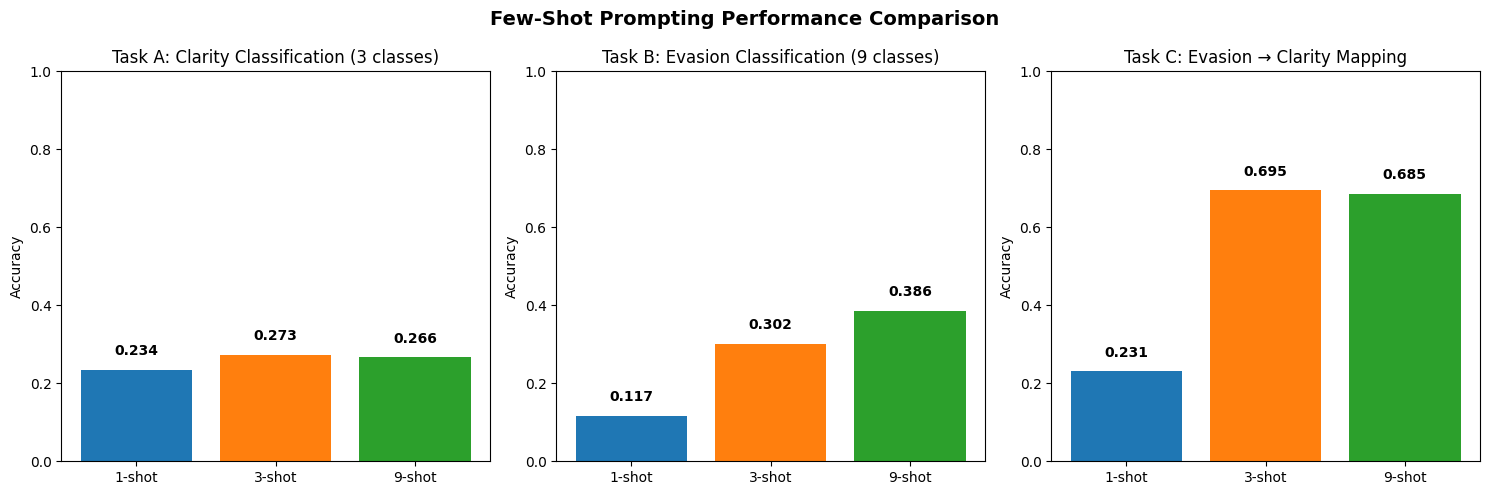

In [57]:
# ── Visualization: Accuracy comparison ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Few-Shot Prompting Performance Comparison', fontsize=14, fontweight='bold')

# Task A: Clarity
clarity_acc = [metrics_1a['accuracy'], metrics_2a['accuracy'], metrics_3a['accuracy']]
ax = axes[0]
ax.bar(['1-shot', '3-shot', '9-shot'], clarity_acc, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Accuracy')
ax.set_title('Task A: Clarity Classification (3 classes)')
ax.set_ylim([0, 1])
for i, v in enumerate(clarity_acc):
    ax.text(i, v + 0.03, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Task B: Evasion
evasion_acc = [metrics_1b['accuracy'], metrics_2b['accuracy'], metrics_3b['accuracy']]
ax = axes[1]
ax.bar(['1-shot', '3-shot', '9-shot'], evasion_acc, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Accuracy')
ax.set_title('Task B: Evasion Classification (9 classes)')
ax.set_ylim([0, 1])
for i, v in enumerate(evasion_acc):
    ax.text(i, v + 0.03, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Task C: Mapping
mapping_acc = [metrics_1c['accuracy'], metrics_2c['accuracy'], metrics_3c['accuracy']]
ax = axes[2]
ax.bar(['1-shot', '3-shot', '9-shot'], mapping_acc, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Accuracy')
ax.set_title('Task C: Evasion → Clarity Mapping')
ax.set_ylim([0, 1])
for i, v in enumerate(mapping_acc):
    ax.text(i, v + 0.03, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'comparison_accuracy_by_task.png', dpi=150, bbox_inches='tight')
print(f'\nSaved comparison plot to {SAVE_DIR / "comparison_accuracy_by_task.png"}')
plt.show()

In [58]:
print('\n' + '='*80)
print('NOTEBOOK EXECUTION COMPLETE')
print('='*80)
print(f'\nAll results saved to: {SAVE_DIR}')
print('\nGenerated files:')
for file in sorted(SAVE_DIR.glob('*')):
    print(f'  - {file.name}')


NOTEBOOK EXECUTION COMPLETE

All results saved to: /content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots

Generated files:
  - 1a_oneshot_clarity_metrics.json
  - 1a_oneshot_clarity_predictions.csv
  - 1b_oneshot_evasion_metrics.json
  - 1b_oneshot_evasion_predictions.csv
  - 1c_oneshot_evasion_to_clarity_metrics.json
  - 1c_oneshot_evasion_to_clarity_predictions.csv
  - 2a_threeshot_clarity_metrics.json
  - 2a_threeshot_clarity_predictions.csv
  - 2b_threeshot_evasion_metrics.json
  - 2b_threeshot_evasion_predictions.csv
  - 2c_threeshot_evasion_to_clarity_metrics.json
  - 2c_threeshot_evasion_to_clarity_predictions.csv
  - 3a_nineshot_clarity_metrics.json
  - 3a_nineshot_clarity_predictions.csv
  - 3b_nineshot_evasion_metrics.json
  - 3b_nineshot_evasion_predictions.csv
  - 3c_nineshot_evasion_to_clarity_metrics.json
  - 3c_nineshot_evasion_to_clarity_predictions.csv
  - comparison_accuracy_by_task.png
  - summary_all_experiments.csv
  - summary_all_experiments.json


COMPREHENSIVE SUMMARY: Few-Shot Prompting Results
Experiment                                     Accuracy   Macro F1
---------------------------------------------------------------------------
Point 1A (One-Shot Clarity)                      0.2338     0.2286
Point 2A (Three-Shot Clarity)                    0.2727     0.2733
Point 3A (Nine-Shot Clarity)                     0.2662     0.2624
Point 1B (One-Shot Evasion)                      0.1169     0.1172
Point 2B (Three-Shot Evasion)                    0.3019     0.2325
Point 3B (Nine-Shot Evasion)                     0.3864     0.2881
Point 1C (1-Shot → Clarity)                      0.2305     0.2852
Point 2C (3-Shot → Clarity)                      0.6948     0.5451
Point 3C (9-Shot → Clarity)                      0.6851     0.6082

Per-class F1 breakdown:
---------------------------------------------------------------------------

Point 1A (One-Shot Clarity):
  Clear Reply                    0.3684  ███████
  Ambivalent            

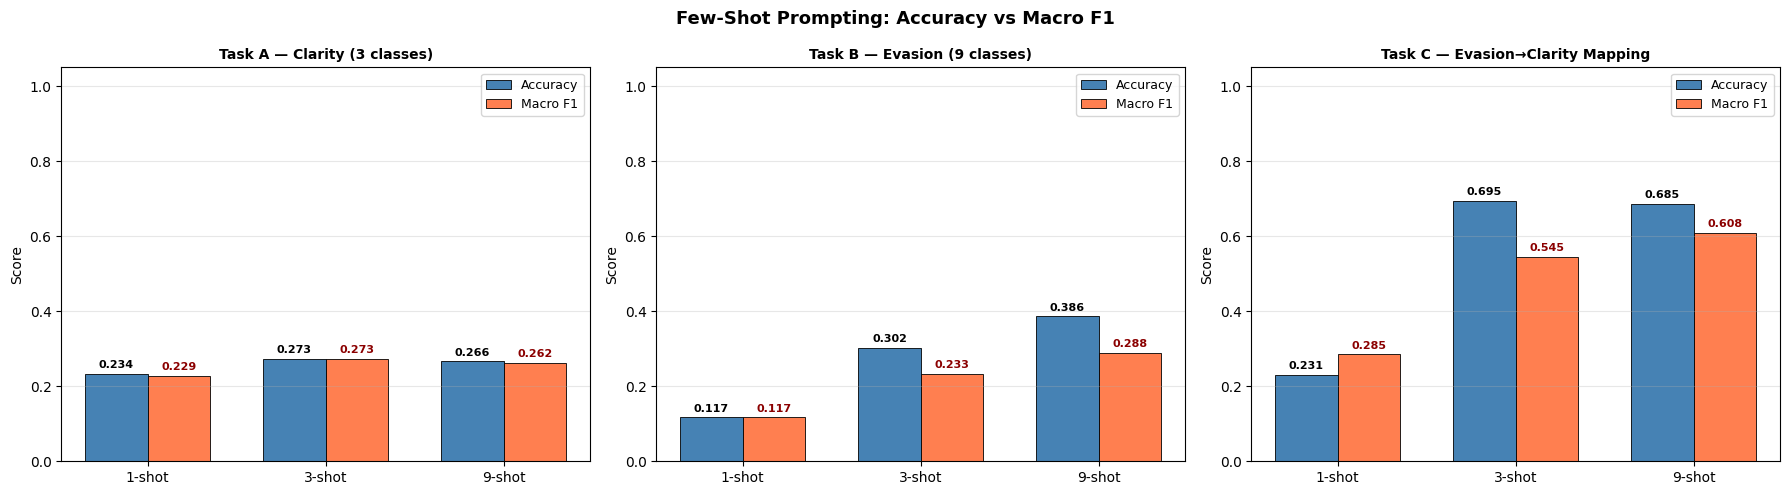

In [59]:
# ── CELLA: Summary completo con Macro F1 ──────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

def macro_f1_from_metrics(metrics_dict):
    """Calcola macro F1 dalla dict dei per-class F1 già salvata."""
    f1_vals = list(metrics_dict['f1'].values())
    return np.mean(f1_vals) if f1_vals else 0.0

# Aggiungi macro_f1 a ogni metrics dict
for name, m in [
    ('1a', metrics_1a), ('2a', metrics_2a), ('3a', metrics_3a),
    ('1b', metrics_1b), ('2b', metrics_2b), ('3b', metrics_3b),
    ('1c', metrics_1c), ('2c', metrics_2c), ('3c', metrics_3c),
]:
    m['macro_f1'] = macro_f1_from_metrics(m)

# ── Tabella riepilogativa ──────────────────────────────────────────────────
rows = [
    ('Point 1A (One-Shot Clarity)',    metrics_1a),
    ('Point 2A (Three-Shot Clarity)',  metrics_2a),
    ('Point 3A (Nine-Shot Clarity)',   metrics_3a),
    ('Point 1B (One-Shot Evasion)',    metrics_1b),
    ('Point 2B (Three-Shot Evasion)',  metrics_2b),
    ('Point 3B (Nine-Shot Evasion)',   metrics_3b),
    ('Point 1C (1-Shot → Clarity)',    metrics_1c),
    ('Point 2C (3-Shot → Clarity)',    metrics_2c),
    ('Point 3C (9-Shot → Clarity)',    metrics_3c),
]

print('='*75)
print('COMPREHENSIVE SUMMARY: Few-Shot Prompting Results')
print('='*75)
print(f'{"Experiment":<45} {"Accuracy":>9} {"Macro F1":>10}')
print('-'*75)
for name, m in rows:
    print(f'{name:<45} {m["accuracy"]:>9.4f} {m["macro_f1"]:>10.4f}')

print()
print('Per-class F1 breakdown:')
print('-'*75)
for name, m in rows:
    print(f'\n{name}:')
    for label, f1 in m['f1'].items():
        bar = '█' * int(f1 * 20)
        print(f'  {label:<30} {f1:.4f}  {bar}')

# ── Grafico: Accuracy + Macro F1 affiancati ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Few-Shot Prompting: Accuracy vs Macro F1', fontsize=13, fontweight='bold')

task_groups = [
    ('Task A — Clarity (3 classes)',
     ['1-shot', '3-shot', '9-shot'],
     [metrics_1a, metrics_2a, metrics_3a]),
    ('Task B — Evasion (9 classes)',
     ['1-shot', '3-shot', '9-shot'],
     [metrics_1b, metrics_2b, metrics_3b]),
    ('Task C — Evasion→Clarity Mapping',
     ['1-shot', '3-shot', '9-shot'],
     [metrics_1c, metrics_2c, metrics_3c]),
]

for ax, (title, xlabels, mlist) in zip(axes, task_groups):
    x = np.arange(len(xlabels))
    w = 0.35
    acc_vals = [m['accuracy']  for m in mlist]
    f1_vals  = [m['macro_f1'] for m in mlist]

    bars_acc = ax.bar(x - w/2, acc_vals, w, label='Accuracy',
                      color='steelblue', edgecolor='black', linewidth=0.6)
    bars_f1  = ax.bar(x + w/2, f1_vals,  w, label='Macro F1',
                      color='coral',     edgecolor='black', linewidth=0.6)

    for bar, val in zip(bars_acc, acc_vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    for bar, val in zip(bars_f1, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold',
                color='darkred')

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'summary_accuracy_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()

---
# POINT 4: Dynamic Few-Shot Prompting (Semantic Retrieval)

Instead of fixed examples, each test sample is paired with the **k most semantically similar**
training examples, retrieved via a FAISS vector index built on `sentence-transformers` embeddings.

**Key design choices:**
- Embedding model: `all-MiniLM-L6-v2` (runs on CPU, ~80MB, fast)
- Similarity: cosine distance on normalised vectors (= inner product)
- Query: concatenation of question + answer (first 300 chars)
- Diversity constraint: at most 1 example per label among the retrieved candidates
- k = 3 (balances coverage and prompt length)

Three sub-tasks mirror Points 1–3:
- **4A**: 3-class clarity classification
- **4B**: 9-class evasion classification  
- **4C**: map 4B predictions → clarity labels (same mapping as 1C/2C/3C)

## 4·0 · Install extra dependencies

In [60]:
# sentence-transformers for embeddings, faiss-cpu for fast nearest-neighbour search
import subprocess
subprocess.run(['pip', 'install', '-q', 'sentence-transformers', 'faiss-cpu'], check=True)
print('Extra dependencies installed.')

Extra dependencies installed.


## 4·1 · Build FAISS Vector Index from Training Set

In [61]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

# ── Embedding model (CPU — does not use VRAM) ──────────────────────────────
EMBEDDER_NAME  = 'sentence-transformers/all-MiniLM-L6-v2'
K_EXAMPLES     = 9      # retrieved examples per query
MAX_QUERY_CHARS = 1500   # truncate answer in query string
MAX_EXAMPLE_CHARS = 1500 # truncate answer shown in prompt

print(f'Loading embedder: {EMBEDDER_NAME} ...')
embedder = SentenceTransformer(EMBEDDER_NAME, device='cpu')
print('Embedder loaded on CPU.')

# ── Build corpus: one entry per training row ───────────────────────────────
# We embed question + answer (truncated) so that similarity captures both
# the type of question asked AND the style of response given.

def make_corpus_text(question: str, answer: str,
                     max_ans: int = MAX_QUERY_CHARS) -> str:
    ans_short = answer[:max_ans] if len(answer) > max_ans else answer
    return f'QUESTION: {question} ANSWER: {ans_short}'


# Separate corpora for clarity and evasion tasks
# (same rows, different label columns — we keep them separate for clarity)
df_train_clarity = df_train[
    df_train['clarity_label'].notna() & (df_train['clarity_label'].str.strip() != '')
].copy().reset_index(drop=True)

df_train_evasion = df_train[
    df_train['evasion_label'].notna() & (df_train['evasion_label'].str.strip() != '')
].copy().reset_index(drop=True)

print(f'Training corpus — clarity: {len(df_train_clarity)} rows')
print(f'Training corpus — evasion: {len(df_train_evasion)} rows')

# ── Encode training corpora ────────────────────────────────────────────────
print('\nEncoding clarity corpus (this takes ~30 s) ...')
clarity_corpus_texts = [
    make_corpus_text(str(r['question']), str(r['interview_answer']))
    for _, r in df_train_clarity.iterrows()
]
clarity_embeddings = embedder.encode(
    clarity_corpus_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,   # cosine similarity = inner product on normalised vecs
    convert_to_numpy=True,
)

print('\nEncoding evasion corpus ...')
evasion_corpus_texts = [
    make_corpus_text(str(r['question']), str(r['interview_answer']))
    for _, r in df_train_evasion.iterrows()
]
evasion_embeddings = embedder.encode(
    evasion_corpus_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
)

# ── Build FAISS indices ────────────────────────────────────────────────────
dim = clarity_embeddings.shape[1]

clarity_index = faiss.IndexFlatIP(dim)   # Inner Product on normalised = cosine
clarity_index.add(clarity_embeddings)

evasion_index = faiss.IndexFlatIP(dim)
evasion_index.add(evasion_embeddings)

print(f'\nFAISS indices built.')
print(f'  Clarity index : {clarity_index.ntotal} vectors, dim={dim}')
print(f'  Evasion index : {evasion_index.ntotal} vectors, dim={dim}')

Loading embedder: sentence-transformers/all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Embedder loaded on CPU.
Training corpus — clarity: 3103 rows
Training corpus — evasion: 3103 rows

Encoding clarity corpus (this takes ~30 s) ...


Batches:   0%|          | 0/49 [00:00<?, ?it/s]


Encoding evasion corpus ...


Batches:   0%|          | 0/49 [00:00<?, ?it/s]


FAISS indices built.
  Clarity index : 3103 vectors, dim=384
  Evasion index : 3103 vectors, dim=384


## 4·2 · Retrieval & Prompt-Building Functions

In [62]:
def retrieve_examples(
    question: str,
    answer: str,
    faiss_index,
    df_corpus: 'pd.DataFrame',
    label_col: str,
    k: int = K_EXAMPLES,
    diversity_cap: int = 1,       # max examples per label
    search_k_multiplier: int = 5, # search k*m candidates, then filter for diversity
) -> list[dict]:
    """
    Retrieve the k most semantically similar training examples.

    Diversity is enforced by allowing at most `diversity_cap` example(s)
    per label among the top search_k_multiplier * k candidates.

    Args:
        question         : Test question string.
        answer           : Test answer string.
        faiss_index      : Pre-built FAISS index.
        df_corpus        : Training DataFrame aligned with the index.
        label_col        : Column name for the label ('clarity_label' or 'evasion_label').
        k                : Number of examples to return.
        diversity_cap    : Maximum examples per distinct label.
        search_k_multiplier : How many extra candidates to fetch before diversity filtering.

    Returns:
        List of dicts with keys: question, answer, label, similarity_score.
    """
    query_text = make_corpus_text(question, answer)
    query_vec  = embedder.encode(
        [query_text], normalize_embeddings=True, convert_to_numpy=True
    )

    n_search = min(k * search_k_multiplier, faiss_index.ntotal)
    scores, indices = faiss_index.search(query_vec, n_search)

    seen_labels: dict[str, int] = {}
    examples: list[dict] = []

    for score, idx in zip(scores[0], indices[0]):
        if idx < 0:
            continue
        row   = df_corpus.iloc[idx]
        label = str(row[label_col]).strip()

        # Diversity constraint
        if seen_labels.get(label, 0) >= diversity_cap:
            continue

        seen_labels[label] = seen_labels.get(label, 0) + 1
        examples.append({
            'question':        str(row['question']),
            'answer':          str(row['interview_answer']),
            'label':           label,
            'similarity_score': float(score),
        })

        if len(examples) == k:
            break

    return examples


def format_dynamic_example(question: str, answer: str, label: str,
                            max_answer_chars: int = MAX_EXAMPLE_CHARS) -> str:
    """Format a single retrieved example for inclusion in the prompt."""
    ans_short = answer[:max_answer_chars] + '...' if len(answer) > max_answer_chars else answer
    return f'QUESTION: {question}\nANSWER: {ans_short}\nCLASSIFICATION: {label}'


def build_dynamic_clarity_prompt(examples: list[dict]) -> str:
    """Build a clarity system prompt from dynamically retrieved examples."""
    prompt = (
        'You are a political evasion analyst. Your task is to classify politician answers '
        'into one of three clarity categories:\n\n'
        '1. **Clear Reply**: The politician directly addresses the question with a substantive response.\n'
        '2. **Ambivalent**: The politician provides a mixed or equivocal response that partially addresses the question.\n'
        '3. **Clear Non-Reply**: The politician evades the question by declining to answer, claiming ignorance, or deflecting.\n\n'
        'Carefully analyze the question and answer pair. Return ONLY the exact classification label, nothing else.\n\n'
        'Here are semantically similar examples from expert annotations:\n\n'
    )
    for i, ex in enumerate(examples, 1):
        prompt += f'Example {i}:\n'
        prompt += format_dynamic_example(ex['question'], ex['answer'], ex['label'])
        prompt += '\n\n'
    prompt += 'Now classify the following question-answer pair:'
    return prompt


def build_dynamic_evasion_prompt(examples: list[dict]) -> str:
    """Build an evasion system prompt from dynamically retrieved examples."""
    prompt = (
        'You are a political evasion analyst. Your task is to classify politician answers '
        'into one of nine evasion sub-categories:\n\n'
        '1. **Explicit**: Direct answer without evasion.\n'
        '2. **Implicit**: Indirect answer that addresses the question obliquely.\n'
        '3. **General**: Vague or overly general response without specifics.\n'
        '4. **Partial/half-answer**: Only partially addresses the question.\n'
        '5. **Dodging**: Avoids answering by changing the subject.\n'
        '6. **Deflection**: Answers a different interpretation of the question.\n'
        '7. **Declining to answer**: Explicitly refuses to respond.\n'
        '8. **Claims ignorance**: States lack of knowledge or information.\n'
        '9. **Clarification**: Asks for clarification instead of answering.\n\n'
        'Carefully analyze the question and answer pair. Return ONLY the exact evasion label, nothing else.\n\n'
        'Here are semantically similar examples from expert annotations:\n\n'
    )
    for i, ex in enumerate(examples, 1):
        prompt += f'Example {i}:\n'
        prompt += format_dynamic_example(ex['question'], ex['answer'], ex['label'])
        prompt += '\n\n'
    prompt += 'Now classify the following question-answer pair:'
    return prompt


# ── Sanity check: show retrieved examples for one test sample ─────────────
print('=== Sanity check: dynamic retrieval ===')
sample_row = df_test_task_a.iloc[0]
sample_q   = str(sample_row['question'])
sample_a   = str(sample_row['interview_answer'])

retrieved = retrieve_examples(
    sample_q, sample_a,
    clarity_index, df_train_clarity, 'clarity_label'
)
print(f'Query Q: {sample_q[:80]}')
print(f'True label: {sample_row["clarity_label"]}')
print(f'Retrieved {len(retrieved)} examples:')
for i, ex in enumerate(retrieved, 1):
    print(f'  [{i}] label={ex["label"]}  sim={ex["similarity_score"]:.3f}  Q: {ex["question"][:60]}')
print()
print('Dynamic prompt preview (first 400 chars):')
print(build_dynamic_clarity_prompt(retrieved)[:400] + '...')
print('\nRetrieval functions defined OK.')

=== Sanity check: dynamic retrieval ===
Query Q:  Inquiring about the status or information regarding the redline.
True label: Ambivalent
Retrieved 3 examples:
  [1] label=Ambivalent  sim=0.668  Q:  What is your red line on North Korea?
  [2] label=Clear Non-Reply  sim=0.562  Q: To what extent do you think China has the ability to talk No
  [3] label=Clear Reply  sim=0.551  Q: President's evaluation of the possibility of North Korea car

Dynamic prompt preview (first 400 chars):
You are a political evasion analyst. Your task is to classify politician answers into one of three clarity categories:

1. **Clear Reply**: The politician directly addresses the question with a substantive response.
2. **Ambivalent**: The politician provides a mixed or equivocal response that partially addresses the question.
3. **Clear Non-Reply**: The politician evades the question by declining ...

Retrieval functions defined OK.


## 4·3 · Inference Utility for Dynamic Few-Shot

In [63]:
def run_dynamic_few_shot_with_checkpoint(
    df: 'pd.DataFrame',
    label_col: str,
    valid_labels: list,
    faiss_index,
    df_corpus: 'pd.DataFrame',
    corpus_label_col: str,
    prompt_builder,           # build_dynamic_clarity_prompt or build_dynamic_evasion_prompt
    exp_name: str,
    csv_path: str,
) -> 'pd.DataFrame':
    """
    Dynamic few-shot inference with row-level checkpoint support.

    For each test row:
    1. Retrieve k semantically similar training examples.
    2. Build a dynamic system prompt with those examples.
    3. Run inference.
    4. Parse and save the result.

    Extra columns saved vs. static few-shot:
      - retrieved_labels   : comma-separated labels of retrieved examples
      - retrieved_sims     : comma-separated similarity scores
      - n_retrieved        : actual number of examples retrieved
    """
    import os
    if os.path.exists(csv_path):
        df_saved = pd.read_csv(csv_path)
        processed_questions = set(df_saved['question'].astype(str))
        print(f'[{exp_name}] Checkpoint found: skipping {len(processed_questions)} rows.')
        mode, header = 'a', False
    else:
        processed_questions = set()
        print(f'[{exp_name}] No checkpoint: starting from scratch.')
        mode, header = 'w', True

    try:
        for _, row in tqdm(df.iterrows(), total=len(df), desc=exp_name):
            q = str(row['question'])
            if q in processed_questions:
                continue

            a    = str(row['interview_answer'])
            true = str(row[label_col])

            try:
                # Step 1: retrieve similar examples
                examples = retrieve_examples(
                    q, a, faiss_index, df_corpus, corpus_label_col
                )

                # Step 2: build dynamic prompt
                system_prompt = prompt_builder(examples)

                # Step 3: inference (reuses predict_few_shot from Section 5)
                raw  = predict_few_shot(system_prompt, q, a)
                pred = parse_label(raw, valid_labels)

                retrieved_labels = ','.join(ex['label'] for ex in examples)
                retrieved_sims   = ','.join(f"{ex['similarity_score']:.3f}" for ex in examples)
                n_retrieved      = len(examples)

            except Exception as e:
                raw              = f'ERROR: {e}'
                pred             = 'PARSE_ERROR'
                retrieved_labels = ''
                retrieved_sims   = ''
                n_retrieved      = 0

            record = {
                'question':        q,
                'answer_snippet':  a[:150],
                'true_label':      true,
                'pred_label':      pred,
                'raw_output':      raw,
                'retrieved_labels': retrieved_labels,
                'retrieved_sims':  retrieved_sims,
                'n_retrieved':     n_retrieved,
            }
            pd.DataFrame([record]).to_csv(csv_path, mode=mode, header=header, index=False)
            mode, header = 'a', False

    except KeyboardInterrupt:
        print(f'\n[!] Interrupted. Progress saved to {csv_path}')

    return pd.read_csv(csv_path)


print('Dynamic few-shot inference function defined.')

Dynamic few-shot inference function defined.


## 4A · Dynamic Few-Shot Clarity Classification (3 classes)

In [64]:
csv_path_4a = SAVE_DIR / '4a_dynamic_clarity_predictions.csv'
df_4a_results = run_dynamic_few_shot_with_checkpoint(
    df=df_test_task_a,
    label_col='clarity_label',
    valid_labels=CLARITY_LABELS,
    faiss_index=clarity_index,
    df_corpus=df_train_clarity,
    corpus_label_col='clarity_label',
    prompt_builder=build_dynamic_clarity_prompt,
    exp_name='Point 4A: Dynamic Clarity',
    csv_path=str(csv_path_4a),
)

metrics_4a = compute_metrics(
    df_4a_results['true_label'].tolist(),
    df_4a_results['pred_label'].tolist(),
    CLARITY_LABELS
)

print(f'\n4A Results — Dynamic Few-Shot Clarity Classification')
print(f'Accuracy: {metrics_4a["accuracy"]:.4f}')
print(f'Per-class F1:')
for label, f1 in metrics_4a['f1'].items():
    print(f'  {label}: {f1:.4f}')
print(f'\nComparison — Clarity Task A:')
print(f'  1A (one-shot):     {metrics_1a["accuracy"]:.4f}')
print(f'  2A (three-shot):   {metrics_2a["accuracy"]:.4f}')
print(f'  3A (nine-shot):    {metrics_3a["accuracy"]:.4f}')
print(f'  4A (dynamic):      {metrics_4a["accuracy"]:.4f}  ← THIS')

# ── Retrieval stats ────────────────────────────────────────────────────────
print(f'\nRetrieval statistics (4A):')
print(f'  Avg examples retrieved : {df_4a_results["n_retrieved"].mean():.2f}')
parse_errors = (df_4a_results['pred_label'] == 'PARSE_ERROR').sum()
print(f'  Parse errors           : {parse_errors}/{len(df_4a_results)}')

# Save metrics
with open(SAVE_DIR / '4a_dynamic_clarity_metrics.json', 'w') as f:
    json.dump(metrics_4a, f, indent=2)
print(f'Saved to {SAVE_DIR}')

[Point 4A: Dynamic Clarity] No checkpoint: starting from scratch.


Point 4A: Dynamic Clarity: 100%|██████████| 308/308 [13:43<00:00,  2.67s/it]


4A Results — Dynamic Few-Shot Clarity Classification
Accuracy: 0.3864
Per-class F1:
  Clear Reply: 0.3608
  Ambivalent: 0.4375
  Clear Non-Reply: 0.3134

Comparison — Clarity Task A:
  1A (one-shot):     0.2338
  2A (three-shot):   0.2727
  3A (nine-shot):    0.2662
  4A (dynamic):      0.3864  ← THIS

Retrieval statistics (4A):
  Avg examples retrieved : 2.86
  Parse errors           : 0/308
Saved to /content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots


## 4B · Dynamic Few-Shot Evasion Classification (9 classes)

In [65]:
csv_path_4b = SAVE_DIR / '4b_dynamic_evasion_predictions.csv'
df_4b_results = run_dynamic_few_shot_with_checkpoint(
    df=df_test_task_b,
    label_col='evasion_label',
    valid_labels=EVASION_LABELS,
    faiss_index=evasion_index,
    df_corpus=df_train_evasion,
    corpus_label_col='evasion_label',
    prompt_builder=build_dynamic_evasion_prompt,
    exp_name='Point 4B: Dynamic Evasion',
    csv_path=str(csv_path_4b),
)

metrics_4b = compute_metrics(
    df_4b_results['true_label'].tolist(),
    df_4b_results['pred_label'].tolist(),
    EVASION_LABELS
)

print(f'\n4B Results — Dynamic Few-Shot Evasion Classification')
print(f'Accuracy: {metrics_4b["accuracy"]:.4f}')
print(f'Per-class F1 (all):')
for label, f1 in metrics_4b['f1'].items():
    print(f'  {label}: {f1:.4f}')
print(f'\nComparison — Evasion Task B:')
print(f'  1B (one-shot):    {metrics_1b["accuracy"]:.4f}')
print(f'  2B (three-shot):  {metrics_2b["accuracy"]:.4f}')
print(f'  3B (nine-shot):   {metrics_3b["accuracy"]:.4f}')
print(f'  4B (dynamic):     {metrics_4b["accuracy"]:.4f}  ← THIS')

print(f'\nRetrieval statistics (4B):')
print(f'  Avg examples retrieved : {df_4b_results["n_retrieved"].mean():.2f}')
parse_errors = (df_4b_results['pred_label'] == 'PARSE_ERROR').sum()
print(f'  Parse errors           : {parse_errors}/{len(df_4b_results)}')

with open(SAVE_DIR / '4b_dynamic_evasion_metrics.json', 'w') as f:
    json.dump(metrics_4b, f, indent=2)
print(f'Saved to {SAVE_DIR}')

[Point 4B: Dynamic Evasion] No checkpoint: starting from scratch.


Point 4B: Dynamic Evasion: 100%|██████████| 308/308 [29:07<00:00,  5.67s/it]


4B Results — Dynamic Few-Shot Evasion Classification
Accuracy: 0.2468
Per-class F1 (all):
  Explicit: 0.4000
  Implicit: 0.1584
  General: 0.2537
  Partial/half-answer: 0.0000
  Dodging: 0.2095
  Deflection: 0.0526
  Declining to answer: 0.2667
  Claims ignorance: 0.3721
  Clarification: 0.0571

Comparison — Evasion Task B:
  1B (one-shot):    0.1169
  2B (three-shot):  0.3019
  3B (nine-shot):   0.3864
  4B (dynamic):     0.2468  ← THIS

Retrieval statistics (4B):
  Avg examples retrieved : 7.15
  Parse errors           : 0/308
Saved to /content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots


## 4C · Map Dynamic Evasion Predictions → Clarity

In [66]:
df_4c_results = df_4b_results.copy()
df_4c_results['mapped_clarity_pred'] = df_4c_results['pred_label'].apply(
    lambda x: EVASION_TO_CLARITY_MAP.get(x, 'UNKNOWN')
)
df_4c_results['mapped_clarity_true'] = df_4c_results['true_label'].apply(
    lambda x: EVASION_TO_CLARITY_MAP.get(x, 'UNKNOWN')
)

metrics_4c = compute_metrics(
    df_4c_results['mapped_clarity_true'].tolist(),
    df_4c_results['mapped_clarity_pred'].tolist(),
    CLARITY_LABELS
)

print(f'\n4C Results — Dynamic Evasion → Clarity Mapping')
print(f'Accuracy (after mapping): {metrics_4c["accuracy"]:.4f}')
print(f'Per-class F1:')
for label, f1 in metrics_4c['f1'].items():
    print(f'  {label}: {f1:.4f}')
print(f'\nComparison — Mapping Task C:')
print(f'  1C (one-shot):    {metrics_1c["accuracy"]:.4f}')
print(f'  2C (three-shot):  {metrics_2c["accuracy"]:.4f}')
print(f'  3C (nine-shot):   {metrics_3c["accuracy"]:.4f}')
print(f'  4C (dynamic):     {metrics_4c["accuracy"]:.4f}  ← THIS')

df_4c_results[['question', 'answer_snippet', 'mapped_clarity_true',
               'mapped_clarity_pred', 'true_label', 'pred_label',
               'retrieved_labels', 'retrieved_sims']].to_csv(
    SAVE_DIR / '4c_dynamic_evasion_to_clarity_predictions.csv', index=False
)
with open(SAVE_DIR / '4c_dynamic_evasion_to_clarity_metrics.json', 'w') as f:
    json.dump(metrics_4c, f, indent=2)
print(f'Saved to {SAVE_DIR}')


4C Results — Dynamic Evasion → Clarity Mapping
Accuracy (after mapping): 0.5584
Per-class F1:
  Clear Reply: 0.4000
  Ambivalent: 0.6789
  Clear Non-Reply: 0.3011

Comparison — Mapping Task C:
  1C (one-shot):    0.2305
  2C (three-shot):  0.6948
  3C (nine-shot):   0.6851
  4C (dynamic):     0.5584  ← THIS
Saved to /content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots


## 4·4 · Retrieval Quality Analysis

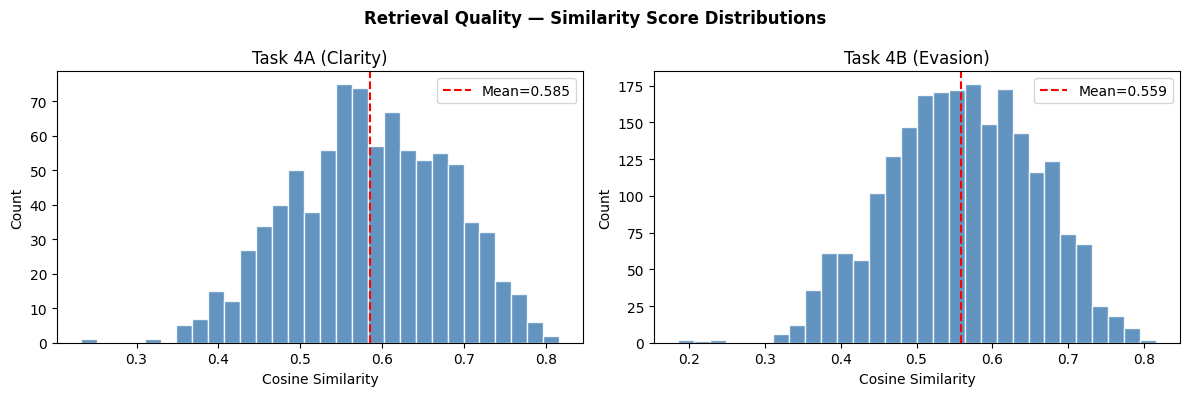

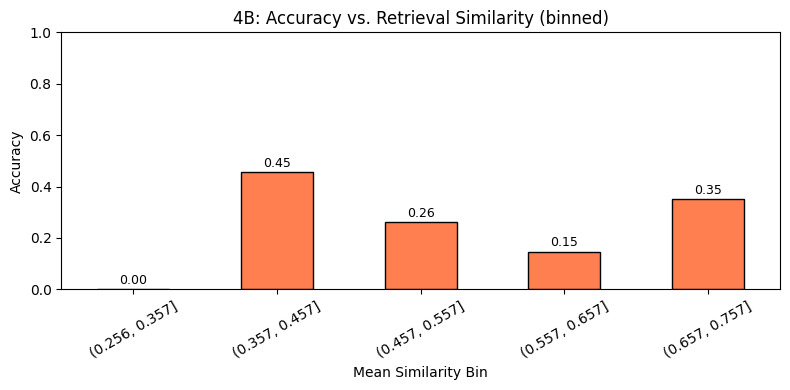

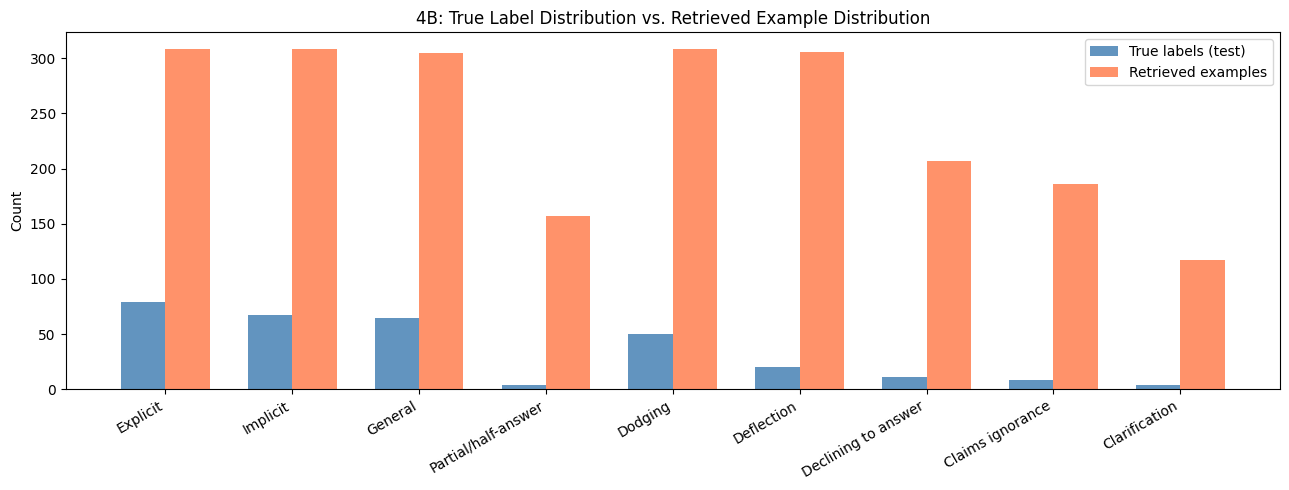

Retrieval analysis plots saved.


In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ── 1. Similarity score distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Retrieval Quality — Similarity Score Distributions', fontweight='bold')

for ax, df_res, title in [
    (axes[0], df_4a_results, 'Task 4A (Clarity)'),
    (axes[1], df_4b_results, 'Task 4B (Evasion)'),
]:
    # Parse comma-separated similarity scores
    all_sims = []
    for sim_str in df_res['retrieved_sims'].dropna():
        try:
            all_sims.extend([float(s) for s in str(sim_str).split(',') if s.strip()])
        except ValueError:
            pass
    ax.hist(all_sims, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.axvline(np.mean(all_sims), color='red', linestyle='--',
               label=f'Mean={np.mean(all_sims):.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / '4_similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 2. Does higher similarity → better accuracy? (4B, binned) ─────────────
df_sim_acc = df_4b_results.copy()
df_sim_acc['mean_sim'] = df_sim_acc['retrieved_sims'].apply(
    lambda s: np.mean([float(x) for x in str(s).split(',') if x.strip()])
    if pd.notna(s) and str(s).strip() else np.nan
)
df_sim_acc['correct'] = (df_sim_acc['true_label'] == df_sim_acc['pred_label']).astype(int)
df_sim_acc = df_sim_acc.dropna(subset=['mean_sim'])

df_sim_acc['sim_bin'] = pd.cut(df_sim_acc['mean_sim'], bins=5)
bin_acc = df_sim_acc.groupby('sim_bin', observed=True)['correct'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
bin_acc.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Mean Similarity Bin')
ax.set_ylabel('Accuracy')
ax.set_title('4B: Accuracy vs. Retrieval Similarity (binned)')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(SAVE_DIR / '4_similarity_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3. Label distribution of retrieved examples (4B) ──────────────────────
all_retrieved_labels = []
for label_str in df_4b_results['retrieved_labels'].dropna():
    all_retrieved_labels.extend([l.strip() for l in str(label_str).split(',') if l.strip()])

from collections import Counter
retrieved_counts = Counter(all_retrieved_labels)
true_counts      = Counter(df_4b_results['true_label'])

labels_union = EVASION_LABELS
x = np.arange(len(labels_union))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, [true_counts.get(l, 0) for l in labels_union],
       w, label='True labels (test)', color='steelblue', alpha=0.85)
ax.bar(x + w/2, [retrieved_counts.get(l, 0) for l in labels_union],
       w, label='Retrieved examples', color='coral', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels_union, rotation=30, ha='right')
ax.set_ylabel('Count')
ax.set_title('4B: True Label Distribution vs. Retrieved Example Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / '4_retrieved_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Retrieval analysis plots saved.')

## 4·5 · Confusion Matrices

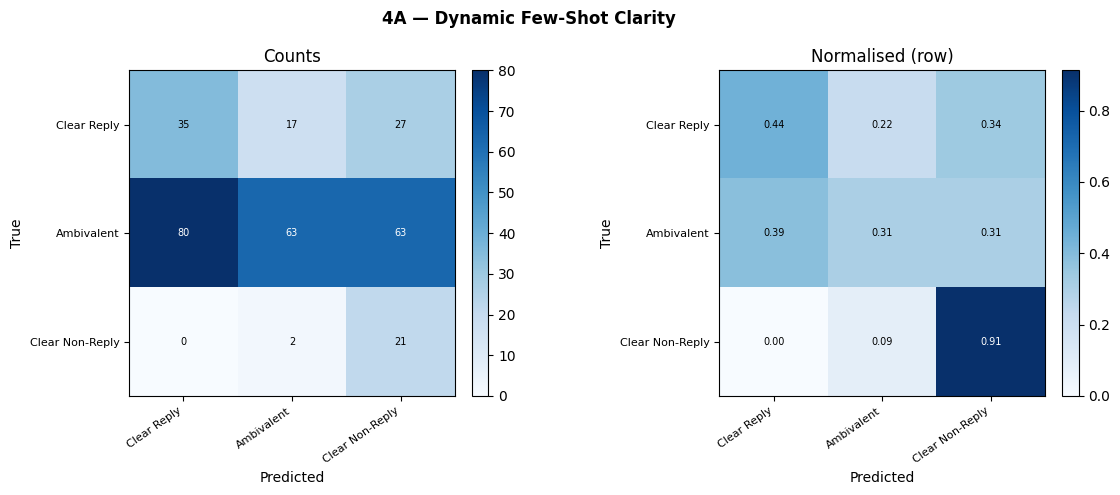

Saved → /content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots/4a_confusion_matrix.png


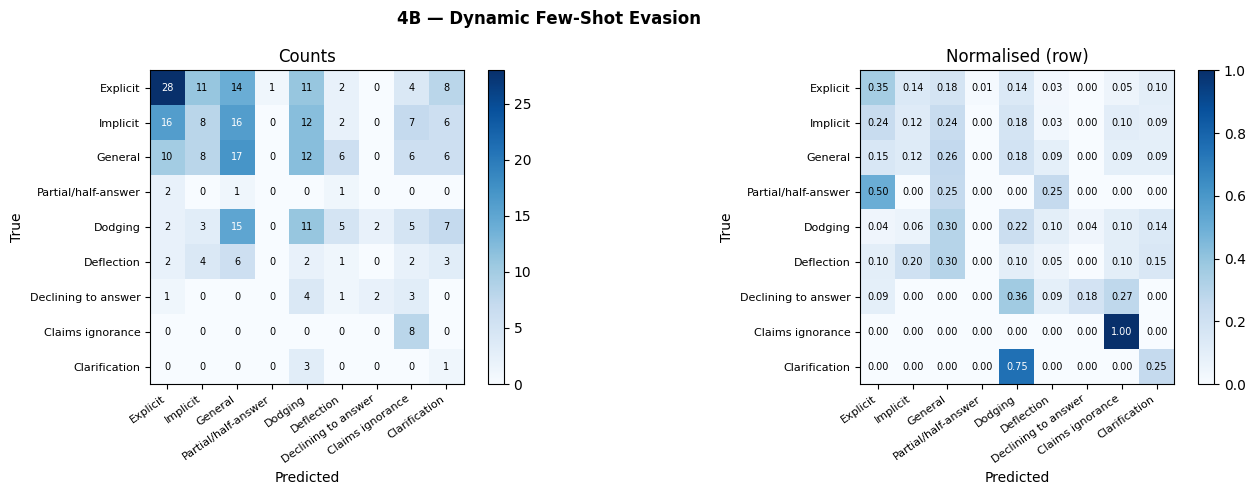

Saved → /content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots/4b_confusion_matrix.png


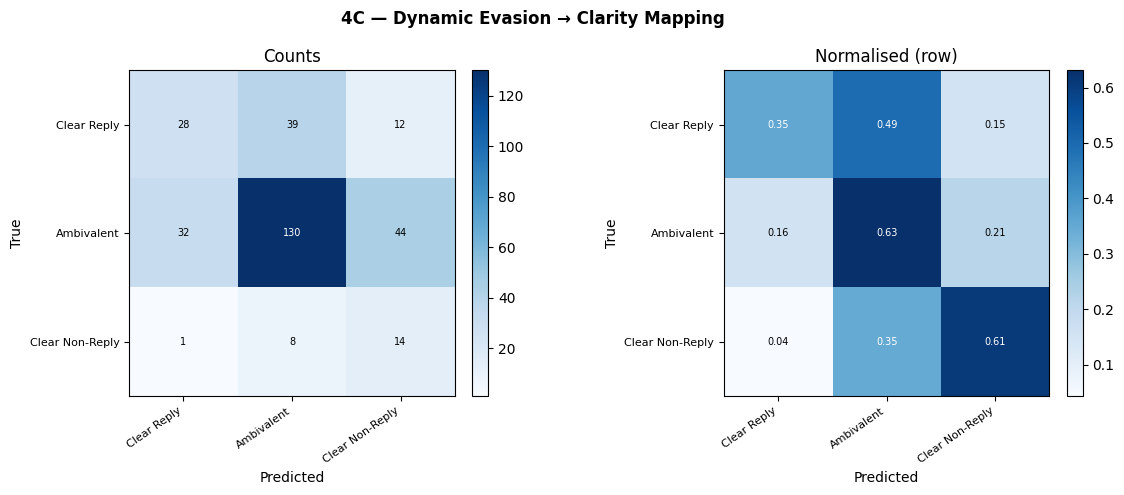

Saved → /content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots/4c_confusion_matrix.png


In [68]:
def plot_confusion_matrix(true_labels, pred_labels, label_names, title, save_path):
    """Plot raw-count + row-normalised confusion matrix side by side."""
    cm      = confusion_matrix(true_labels, pred_labels, labels=label_names)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    n       = len(label_names)

    fig, axes = plt.subplots(1, 2, figsize=(max(12, n * 1.6), 5))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for ax, mat, subtitle in zip(axes, [cm, cm_norm], ['Counts', 'Normalised (row)']):
        im = ax.imshow(mat, cmap='Blues')
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_xticklabels(label_names, rotation=35, ha='right', fontsize=8)
        ax.set_yticklabels(label_names, fontsize=8)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(subtitle)
        thresh = mat.max() / 2
        for i in range(n):
            for j in range(n):
                val = f'{mat[i,j]:.2f}' if subtitle != 'Counts' else str(int(mat[i,j]))
                ax.text(j, i, val, ha='center', va='center', fontsize=7,
                        color='white' if mat[i,j] > thresh else 'black')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


# Filter out PARSE_ERROR rows for CM
df_4a_valid = df_4a_results[df_4a_results['pred_label'] != 'PARSE_ERROR']
df_4b_valid = df_4b_results[df_4b_results['pred_label'] != 'PARSE_ERROR']
df_4c_valid = df_4c_results[df_4c_results['mapped_clarity_pred'] != 'UNKNOWN']

plot_confusion_matrix(
    df_4a_valid['true_label'], df_4a_valid['pred_label'],
    CLARITY_LABELS,
    '4A — Dynamic Few-Shot Clarity',
    SAVE_DIR / '4a_confusion_matrix.png'
)

plot_confusion_matrix(
    df_4b_valid['true_label'], df_4b_valid['pred_label'],
    EVASION_LABELS,
    '4B — Dynamic Few-Shot Evasion',
    SAVE_DIR / '4b_confusion_matrix.png'
)

plot_confusion_matrix(
    df_4c_valid['mapped_clarity_true'], df_4c_valid['mapped_clarity_pred'],
    CLARITY_LABELS,
    '4C — Dynamic Evasion → Clarity Mapping',
    SAVE_DIR / '4c_confusion_matrix.png'
)

## 4·6 · Full Comparison: Points 1–4


  FULL COMPARISON — Points 1 → 4 (all strategies, all tasks)
ID   Strategy        Task  Accuracy  Macro F1
1A   One-Shot Clarity (A)  0.233766  0.228592
2A Three-Shot Clarity (A)  0.272727  0.273342
3A  Nine-Shot Clarity (A)  0.266234  0.262394
4A    Dynamic Clarity (A)  0.386364  0.370586
1B   One-Shot Evasion (B)  0.116883  0.117210
2B Three-Shot Evasion (B)  0.301948  0.232524
3B  Nine-Shot Evasion (B)  0.386364  0.288100
4B    Dynamic Evasion (B)  0.246753  0.196689
1C   One-Shot Mapping (C)  0.230519  0.285199
2C Three-Shot Mapping (C)  0.694805  0.545113
3C  Nine-Shot Mapping (C)  0.685065  0.608244
4C    Dynamic Mapping (C)  0.558442  0.459975


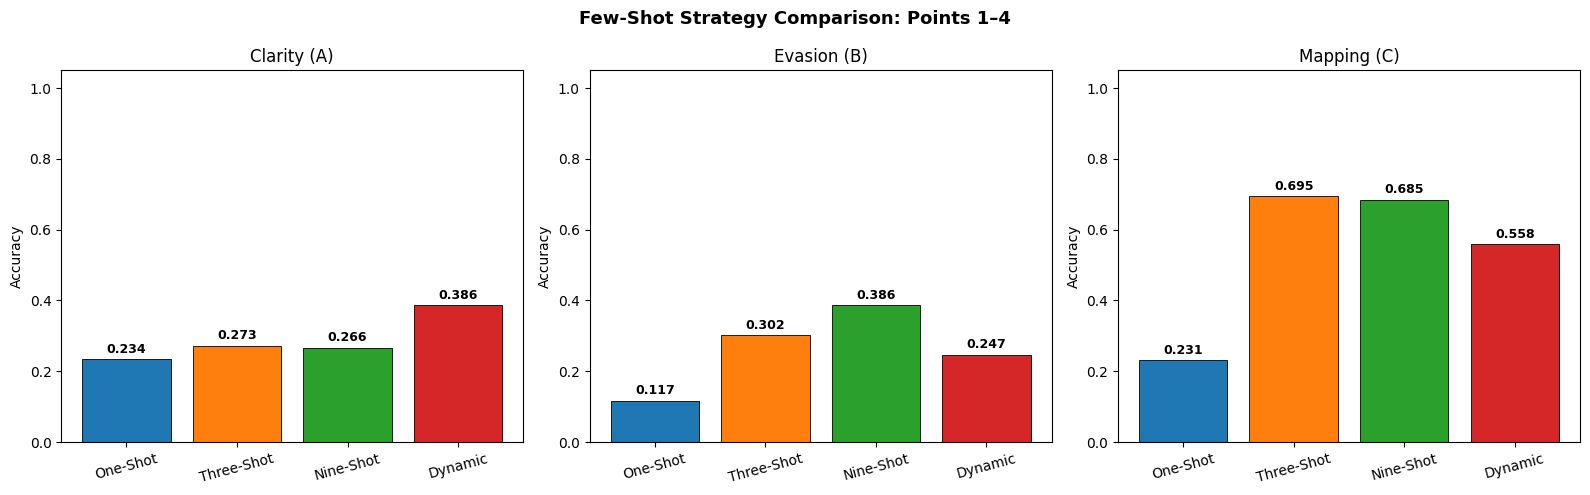

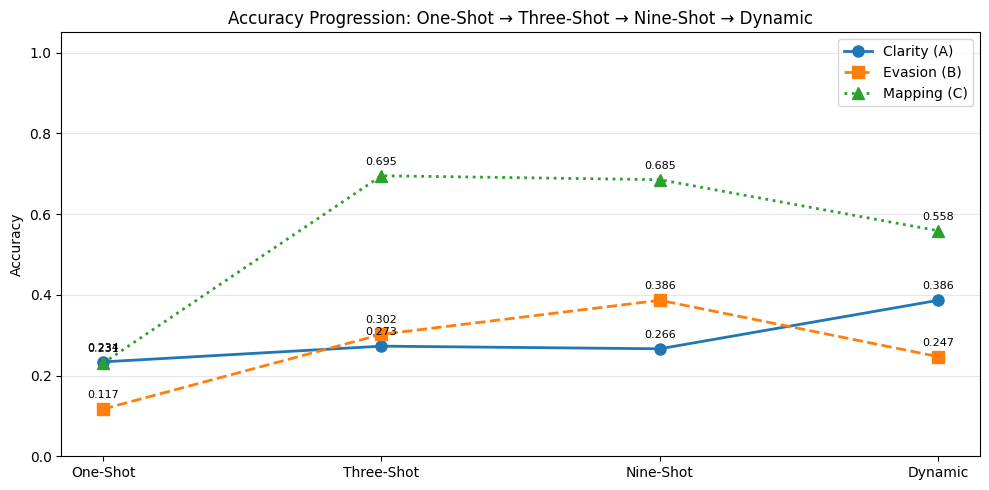


Full summary saved → /content/drive/MyDrive/progettoLLM/CLARITY/results/few_shots/summary_points_1_to_4.csv

── Best strategy per task (Accuracy) ──
  Clarity (A): Dynamic  (0.3864)
  Evasion (B): Nine-Shot  (0.3864)
  Mapping (C): Three-Shot  (0.6948)


In [69]:
import json
from pathlib import Path

# Helper: load metric from memory or from saved JSON
def safe_metric(metrics_var, key, fallback_json: Path):
    try:
        return metrics_var[key]
    except Exception:
        with open(fallback_json) as f:
            return json.load(f)[key]


# ── Accuracy table ─────────────────────────────────────────────────────────
rows_summary = [
    ('1A', 'One-Shot',   'Clarity (A)', metrics_1a),
    ('2A', 'Three-Shot', 'Clarity (A)', metrics_2a),
    ('3A', 'Nine-Shot',  'Clarity (A)', metrics_3a),
    ('4A', 'Dynamic',    'Clarity (A)', metrics_4a),
    ('1B', 'One-Shot',   'Evasion (B)', metrics_1b),
    ('2B', 'Three-Shot', 'Evasion (B)', metrics_2b),
    ('3B', 'Nine-Shot',  'Evasion (B)', metrics_3b),
    ('4B', 'Dynamic',    'Evasion (B)', metrics_4b),
    ('1C', 'One-Shot',   'Mapping (C)', metrics_1c),
    ('2C', 'Three-Shot', 'Mapping (C)', metrics_2c),
    ('3C', 'Nine-Shot',  'Mapping (C)', metrics_3c),
    ('4C', 'Dynamic',    'Mapping (C)', metrics_4c),
]

df_summary_full = pd.DataFrame([
    {'ID': r[0], 'Strategy': r[1], 'Task': r[2],
     'Accuracy': r[3]['accuracy'],
     'Macro F1': sum(r[3]['f1'].values()) / len(r[3]['f1']) if r[3]['f1'] else 0.0}
    for r in rows_summary
])

print('\n' + '='*70)
print('  FULL COMPARISON — Points 1 → 4 (all strategies, all tasks)')
print('='*70)
print(df_summary_full.to_string(index=False))


# ── Bar chart: accuracy by task and strategy ───────────────────────────────
strategies  = ['One-Shot', 'Three-Shot', 'Nine-Shot', 'Dynamic']
task_labels = ['Clarity (A)', 'Evasion (B)', 'Mapping (C)']
colors      = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Few-Shot Strategy Comparison: Points 1–4', fontsize=13, fontweight='bold')

for ax, task in zip(axes, task_labels):
    task_df = df_summary_full[df_summary_full['Task'] == task]
    acc_vals = [task_df[task_df['Strategy'] == s]['Accuracy'].values[0]
                if len(task_df[task_df['Strategy'] == s]) > 0 else 0.0
                for s in strategies]
    bars = ax.bar(strategies, acc_vals, color=colors, edgecolor='black', linewidth=0.6)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Accuracy')
    ax.set_title(task)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, acc_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR / '4_full_comparison_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Line plot: progression across strategies ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(strategies))

for task, marker, ls in [
    ('Clarity (A)', 'o', '-'),
    ('Evasion (B)', 's', '--'),
    ('Mapping (C)', '^', ':'),
]:
    task_df  = df_summary_full[df_summary_full['Task'] == task]
    acc_vals = [task_df[task_df['Strategy'] == s]['Accuracy'].values[0]
                if len(task_df[task_df['Strategy'] == s]) > 0 else np.nan
                for s in strategies]
    ax.plot(x, acc_vals, marker=marker, linestyle=ls, linewidth=2, label=task, markersize=8)
    for xi, v in zip(x, acc_vals):
        if not np.isnan(v):
            ax.annotate(f'{v:.3f}', (xi, v), textcoords='offset points',
                        xytext=(0, 8), ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Accuracy Progression: One-Shot → Three-Shot → Nine-Shot → Dynamic')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / '4_progression_line_plot.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Save full summary ──────────────────────────────────────────────────────
df_summary_full.to_csv(SAVE_DIR / 'summary_points_1_to_4.csv', index=False)
print(f'\nFull summary saved → {SAVE_DIR / "summary_points_1_to_4.csv"}')

print('\n── Best strategy per task (Accuracy) ──')
for task in task_labels:
    task_df  = df_summary_full[df_summary_full['Task'] == task]
    best_row = task_df.loc[task_df['Accuracy'].idxmax()]
    print(f'  {task}: {best_row["Strategy"]}  ({best_row["Accuracy"]:.4f})')

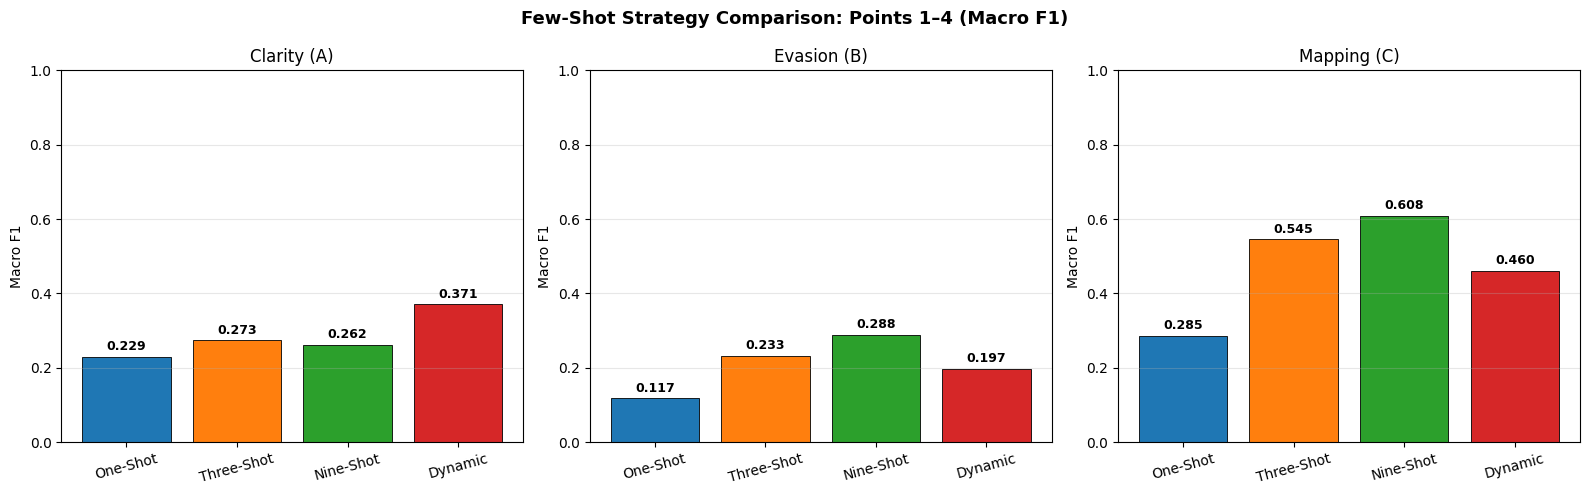

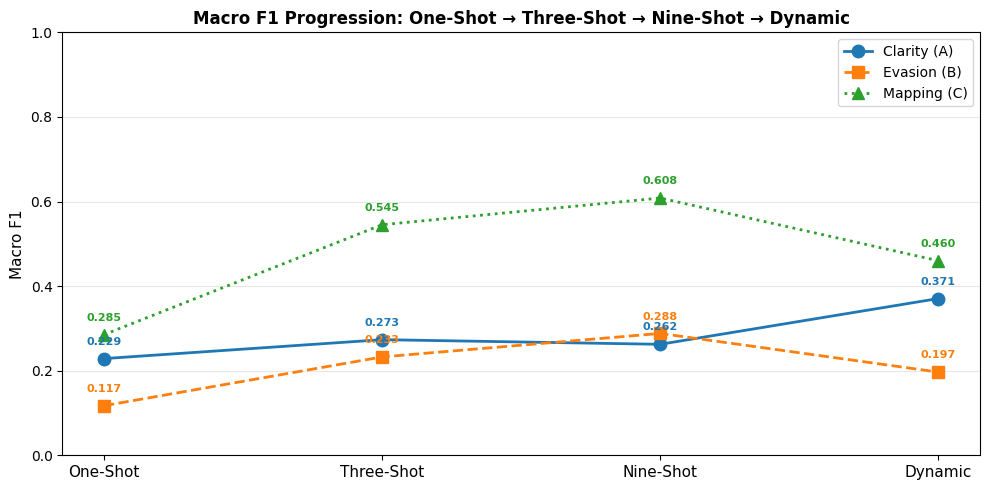


  MACRO F1 COMPARISON — Points 1 → 4
Task              One-Shot   Three-Shot   Nine-Shot   Dynamic
-----------------------------------------------------------------
Clarity (A)         0.229       0.273       0.262       0.371 ←
Evasion (B)         0.117       0.233       0.288 ←     0.197  
Mapping (C)         0.285       0.545       0.608 ←     0.460  

Note: ← indica il metodo migliore per task su Macro F1


In [70]:
# ── CELLA: Grafici comparativi 1→4 con Macro F1 ───────────────────────────

import json
import numpy as np
import matplotlib.pyplot as plt

def load_macro_f1(metrics_var, fallback_json_path):
    """Carica macro F1 dalla variabile in memoria o dal JSON su disco."""
    try:
        f1_vals = list(metrics_var['f1'].values())
        return np.mean(f1_vals) if f1_vals else 0.0
    except Exception:
        with open(fallback_json_path) as f:
            m = json.load(f)
        f1_vals = list(m.get('f1', {}).values())
        return np.mean(f1_vals) if f1_vals else 0.0

# Raccoglie Macro F1 per tutti i punti e task
f1_data = {
    'Clarity (A)': {
        'One-Shot':   load_macro_f1(metrics_1a, SAVE_DIR / '1a_oneshot_clarity_metrics.json'),
        'Three-Shot': load_macro_f1(metrics_2a, SAVE_DIR / '2a_threeshot_clarity_metrics.json'),
        'Nine-Shot':  load_macro_f1(metrics_3a, SAVE_DIR / '3a_nineshot_clarity_metrics.json'),
        'Dynamic':    load_macro_f1(metrics_4a, SAVE_DIR / '4a_dynamic_clarity_metrics.json'),
    },
    'Evasion (B)': {
        'One-Shot':   load_macro_f1(metrics_1b, SAVE_DIR / '1b_oneshot_evasion_metrics.json'),
        'Three-Shot': load_macro_f1(metrics_2b, SAVE_DIR / '2b_threeshot_evasion_metrics.json'),
        'Nine-Shot':  load_macro_f1(metrics_3b, SAVE_DIR / '3b_nineshot_evasion_metrics.json'),
        'Dynamic':    load_macro_f1(metrics_4b, SAVE_DIR / '4b_dynamic_evasion_metrics.json'),
    },
    'Mapping (C)': {
        'One-Shot':   load_macro_f1(metrics_1c, SAVE_DIR / '1c_oneshot_evasion_to_clarity_metrics.json'),
        'Three-Shot': load_macro_f1(metrics_2c, SAVE_DIR / '2c_threeshot_evasion_to_clarity_metrics.json'),
        'Nine-Shot':  load_macro_f1(metrics_3c, SAVE_DIR / '3c_nineshot_evasion_to_clarity_metrics.json'),
        'Dynamic':    load_macro_f1(metrics_4c, SAVE_DIR / '4c_dynamic_evasion_to_clarity_metrics.json'),
    },
}

strategies  = ['One-Shot', 'Three-Shot', 'Nine-Shot', 'Dynamic']
task_labels = ['Clarity (A)', 'Evasion (B)', 'Mapping (C)']
colors      = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# ── Grafico 7 bis: Bar chart Macro F1 ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Few-Shot Strategy Comparison: Points 1–4 (Macro F1)',
             fontsize=13, fontweight='bold')

for ax, task in zip(axes, task_labels):
    vals = [f1_data[task][s] for s in strategies]
    bars = ax.bar(strategies, vals, color=colors, edgecolor='black', linewidth=0.6)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Macro F1')
    ax.set_title(task)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR / '4_full_comparison_macro_f1_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Grafico 8 bis: Line plot Macro F1 ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(strategies))

for task, marker, ls, color in [
    ('Clarity (A)', 'o', '-',  '#1f77b4'),
    ('Evasion (B)', 's', '--', '#ff7f0e'),
    ('Mapping (C)', '^', ':',  '#2ca02c'),
]:
    vals = [f1_data[task][s] for s in strategies]
    ax.plot(x, vals, marker=marker, linestyle=ls, linewidth=2,
            label=task, markersize=9, color=color)
    for xi, v in zip(x, vals):
        ax.annotate(f'{v:.3f}', (xi, v),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8, fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=11)
ax.set_ylabel('Macro F1', fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_title('Macro F1 Progression: One-Shot → Three-Shot → Nine-Shot → Dynamic',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / '4_progression_macro_f1_line.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tabella numerica completa ──────────────────────────────────────────────
print('\n' + '='*65)
print('  MACRO F1 COMPARISON — Points 1 → 4')
print('='*65)
print(f'{"Task":<15} {"One-Shot":>10} {"Three-Shot":>12} '
      f'{"Nine-Shot":>11} {"Dynamic":>9}')
print('-'*65)
for task in task_labels:
    vals = [f1_data[task][s] for s in strategies]
    best_idx = int(np.argmax(vals))
    row = f'{task:<15}'
    for i, (s, v) in enumerate(zip(strategies, vals)):
        marker = ' ←' if i == best_idx else '  '
        row += f'{v:>10.3f}{marker}'
    print(row)

print('\nNote: ← indica il metodo migliore per task su Macro F1')